# SPY-Like Market Pull

This notebook uses the current `mykalshi` discovery, market-history, trade-history,
and orderbook helpers to pull a focused universe of Kalshi markets tied to broad
equity-index levels in the future.

The default search is aimed at SPY-like underlyings:

- S&P 500
- Nasdaq-100
- Dow Jones
- Russell 2000

It intentionally filters out unrelated results like S&P 500 constituent add/remove
markets, because those are about index membership rather than the index value itself.

Read this notebook in two layers:

1. **Raw Kalshi layer**: what contracts Kalshi actually lists and what quoted probabilities
   come directly from those contracts
2. **Derived notebook layer**: classifications and distribution views built from the raw contracts


## Provenance Rules

This notebook now separates:

- **Raw Kalshi contracts and fields**: market metadata, strike bounds, event titles, order book quotes,
  last price, bid/ask, open interest, volume, and the actual market set discovered from Kalshi
- **Notebook-derived views**: contract classification, midpoint probabilities, normalized partition
  probabilities, threshold-curve diagnostics, and bucketized probability-mass approximations

The goal is to keep visibility clear:

1. What Kalshi already lists directly as contracts
2. What this notebook computes from those contracts


In [53]:
import importlib.util
import json
import os
import site
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists() and (PROJECT_ROOT.parent / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in os.sys.path:
    os.sys.path.insert(0, str(PROJECT_ROOT))

def bootstrap_repo_venv_site_packages(project_root: Path):
    version_tag = f"python{os.sys.version_info.major}.{os.sys.version_info.minor}"
    candidates = [
        project_root / ".venv" / "Lib" / "site-packages",
        project_root / ".venv" / "lib" / version_tag / "site-packages",
    ]
    for candidate in candidates:
        if candidate.exists():
            site.addsitedir(str(candidate))
            return candidate
    return None

required_packages = ("pandas", "matplotlib")
missing = [name for name in required_packages if importlib.util.find_spec(name) is None]
venv_site_packages = None
if missing:
    venv_site_packages = bootstrap_repo_venv_site_packages(PROJECT_ROOT)
    missing = [name for name in required_packages if importlib.util.find_spec(name) is None]
if missing:
    install_target = f'{PROJECT_ROOT}[analysis,storage,websocket]'
    raise ModuleNotFoundError(
        "Notebook dependencies are missing in the current kernel "
        f"({os.sys.executable}). Missing: {', '.join(missing)}. "
        f'Run `%pip install -e "{install_target}"` in this notebook, '
        'or switch VS Code/Jupyter to the "mykalshi (.venv)" kernel.'
    )
if venv_site_packages is not None and ".venv" not in os.sys.executable:
    print(
        "Notebook is running outside the repo venv; "
        f"using packages from {venv_site_packages}"
    )

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from mykalshi import market
from mykalshi.research import ResearchSession

pd.set_option("display.max_columns", 200)
%config InlineBackend.figure_format = "retina"


In [54]:
QUERY_TERMS = (
    "S&P",
    "SP500",
    "Nasdaq-100",
    "Nasdaq",
    "Dow Jones",
    "Russell 2000",
)
STATUS = "open"
PERIOD_INTERVAL = "d"
INCLUDE_TRADE_HISTORY = True
INCLUDE_ORDERBOOK = True
TRADE_START_TS = None
TRADE_END_TS = None
MAX_MARKETS = None
OUTPUT_DIR = PROJECT_ROOT / "data" / "spy_like_market_pull"


In [55]:
session = ResearchSession()

def _joined_text(match):
    fields = [
        match.category,
        match.series_ticker,
        match.series_title,
        match.event_ticker,
        match.event_title,
        match.event_subtitle,
        match.market_ticker,
        match.market_title,
        match.market_subtitle,
    ]
    return " ".join(str(value or "") for value in fields).casefold()

def _looks_like_equity_index_value_market(match):
    text = _joined_text(match)
    index_tokens = ("s&p", "sp500", "nasdaq", "nasdaq-100", "dow", "russell")
    value_tokens = ("above", "below", "positive", "close price", "how high", "how low", "maximum", "minimum", "value")
    exclude_tokens = (
        "removed from the s&p 500",
        "added to the s&p 500",
        "removed from sp500",
        "added to sp500",
    )
    if any(token in text for token in exclude_tokens):
        return False
    if not any(token in text for token in index_tokens):
        return False
    if match.category and str(match.category).casefold() == "financials":
        return True
    return any(token in text for token in value_tokens)

def discover_equity_index_markets(session, *, query_terms=QUERY_TERMS, status=STATUS, max_markets=MAX_MARKETS):
    discovered = {}
    for query in query_terms:
        for match in session.search_markets(query=query, status=status, limit=50):
            if not _looks_like_equity_index_value_market(match):
                continue
            discovered[match.market_ticker] = match
    matches = sorted(discovered.values(), key=lambda item: (item.series_ticker or "", item.event_ticker or "", item.market_ticker))
    if max_markets is not None:
        matches = matches[:max_markets]
    return matches

def _frame_from_rows(rows, sort_columns):
    frame = pd.DataFrame(rows)
    present_sort_columns = [column for column in sort_columns if column in frame.columns]
    if present_sort_columns:
        frame = frame.sort_values(present_sort_columns, na_position="last").reset_index(drop=True)
    return frame

def _infer_underlying(row):
    series_ticker = str(row.get("series_ticker") or "")
    text = " ".join(str(row.get(column) or "") for column in ("series_title", "event_title", "market_title", "market_subtitle")).casefold()
    if "nasdaq" in text or "KXNASDAQ100" in series_ticker:
        return "Nasdaq-100"
    if "s&p" in text or "sp500" in text or "KXINX" in series_ticker:
        return "S&P 500"
    return "Other"

def _infer_distribution_family(row):
    series_ticker = str(row.get("series_ticker") or "")
    title_text = " ".join(str(row.get(column) or "") for column in ("series_title", "event_title", "market_title")).casefold()
    if "max" in series_ticker.casefold() or "how high" in title_text:
        return "annual_max"
    if "min" in series_ticker.casefold() or "how low" in title_text:
        return "annual_min"
    return "terminal_close"

def _probability_columns(frame):
    result = frame.copy()
    bid = pd.to_numeric(result.get("yes_bid_dollars", result.get("yes_bid")), errors="coerce")
    ask = pd.to_numeric(result.get("yes_ask_dollars", result.get("yes_ask")), errors="coerce")
    last = pd.to_numeric(result.get("last_price_dollars", result.get("last_price")), errors="coerce")
    result["bid_prob"] = bid
    result["ask_prob"] = ask
    result["last_prob"] = last
    result["mid_prob"] = (bid + ask) / 2.0
    result["mid_prob"] = result["mid_prob"].where(result["mid_prob"].notna(), bid)
    result["mid_prob"] = result["mid_prob"].where(result["mid_prob"].notna(), ask)
    result["mid_prob"] = result["mid_prob"].where(result["mid_prob"].notna(), last)
    return result

def classify_market_table(markets_df):
    classified = _probability_columns(markets_df)
    if classified.empty:
        return classified
    classified["underlying"] = classified.apply(_infer_underlying, axis=1)
    classified["distribution_family"] = classified.apply(_infer_distribution_family, axis=1)
    classified["contract_form"] = classified["strike_type"].fillna("unknown")
    classified["lower_bound"] = pd.to_numeric(classified.get("floor_strike"), errors="coerce")
    classified["upper_bound"] = pd.to_numeric(classified.get("cap_strike"), errors="coerce")
    less_mask = classified["contract_form"].eq("less")
    greater_mask = classified["contract_form"].eq("greater")
    between_mask = classified["contract_form"].eq("between")
    classified.loc[less_mask & classified["upper_bound"].isna(), "upper_bound"] = classified.loc[less_mask & classified["upper_bound"].isna(), "lower_bound"]
    classified.loc[less_mask, "lower_bound"] = pd.NA
    classified.loc[greater_mask, "upper_bound"] = pd.NA
    classified["threshold"] = classified["lower_bound"]
    classified.loc[less_mask, "threshold"] = classified.loc[less_mask, "upper_bound"]
    event_has_between = classified.groupby("event_ticker")["contract_form"].transform(lambda values: values.eq("between").any())
    classified["family_structure"] = "threshold_ladder"
    classified.loc[event_has_between & classified["distribution_family"].eq("terminal_close"), "family_structure"] = "partition_family"
    classified.loc[(~event_has_between) & classified["distribution_family"].eq("terminal_close") & greater_mask, "family_structure"] = "standalone_threshold"
    classified["market_archetype"] = "other"
    classified.loc[classified["distribution_family"].eq("annual_max") & greater_mask, "market_archetype"] = "annual_max_upper_tail"
    classified.loc[classified["distribution_family"].eq("annual_min") & less_mask, "market_archetype"] = "annual_min_lower_tail"
    classified.loc[classified["distribution_family"].eq("terminal_close") & classified["family_structure"].eq("partition_family") & between_mask, "market_archetype"] = "terminal_range_bin"
    classified.loc[classified["distribution_family"].eq("terminal_close") & classified["family_structure"].eq("partition_family") & less_mask, "market_archetype"] = "terminal_left_tail"
    classified.loc[classified["distribution_family"].eq("terminal_close") & classified["family_structure"].eq("partition_family") & greater_mask, "market_archetype"] = "terminal_right_tail"
    classified.loc[classified["distribution_family"].eq("terminal_close") & classified["family_structure"].eq("standalone_threshold") & greater_mask, "market_archetype"] = "terminal_reference_upper_tail"
    sort_columns = ["underlying", "distribution_family", "event_ticker", "lower_bound", "upper_bound", "market_ticker"]
    return classified.sort_values(sort_columns, na_position="last").reset_index(drop=True)

def build_family_summary(classified_df):
    if classified_df.empty:
        return pd.DataFrame()
    summary = classified_df.groupby(["underlying", "distribution_family", "family_structure", "market_archetype", "series_ticker", "event_ticker"], dropna=False).size().rename("market_count").reset_index()
    return summary.sort_values(["underlying", "distribution_family", "series_ticker", "market_archetype"], na_position="last").reset_index(drop=True)

def build_partition_distribution(classified_df, *, underlying):
    partition = classified_df[(classified_df["underlying"] == underlying) & (classified_df["distribution_family"] == "terminal_close") & (classified_df["family_structure"] == "partition_family")].copy()
    if partition.empty:
        return partition
    partition["bin_low"] = partition["lower_bound"]
    partition["bin_high"] = partition["upper_bound"]
    partition.loc[partition["market_archetype"] == "terminal_left_tail", "bin_label"] = "< " + partition.loc[partition["market_archetype"] == "terminal_left_tail", "upper_bound"].round(2).astype(str)
    partition.loc[partition["market_archetype"] == "terminal_right_tail", "bin_label"] = ">= " + partition.loc[partition["market_archetype"] == "terminal_right_tail", "lower_bound"].round(2).astype(str)
    between_rows = partition["market_archetype"] == "terminal_range_bin"
    partition.loc[between_rows, "bin_label"] = partition.loc[between_rows, "lower_bound"].round(2).astype(str) + " to " + partition.loc[between_rows, "upper_bound"].round(2).astype(str)
    probability_sum = partition["mid_prob"].sum(skipna=True)
    partition["partition_prob_sum_mid"] = probability_sum
    partition["mid_prob_normalized"] = partition["mid_prob"] / probability_sum if probability_sum else pd.NA
    return partition.sort_values(["event_ticker", "bin_low", "bin_high", "market_ticker"], na_position="first").reset_index(drop=True)

def build_threshold_curve(classified_df, *, underlying, distribution_family):
    curve = classified_df[(classified_df["underlying"] == underlying) & (classified_df["distribution_family"] == distribution_family)].copy()
    if curve.empty:
        return curve
    if distribution_family == "annual_max":
        curve["threshold"] = curve["lower_bound"]
        curve["curve_type"] = "survival_prob"
        curve["curve_label"] = "P(max >= threshold)"
        curve = curve.sort_values("threshold").reset_index(drop=True)
        curve["adjacent_prob_change"] = curve["mid_prob"].shift(1) - curve["mid_prob"]
        curve["monotone_ok"] = curve["mid_prob"].diff().fillna(0.0) <= 1e-9
    elif distribution_family == "annual_min":
        curve["threshold"] = curve["upper_bound"]
        curve["curve_type"] = "cdf_prob"
        curve["curve_label"] = "P(min <= threshold)"
        curve = curve.sort_values("threshold").reset_index(drop=True)
        curve["adjacent_prob_change"] = curve["mid_prob"] - curve["mid_prob"].shift(1)
        curve["monotone_ok"] = curve["mid_prob"].diff().fillna(0.0) >= -1e-9
    else:
        curve["threshold"] = curve["lower_bound"]
        curve["curve_type"] = "survival_prob"
        curve["curve_label"] = "P(close >= threshold)"
        curve = curve.sort_values("threshold").reset_index(drop=True)
        curve["adjacent_prob_change"] = curve["mid_prob"].shift(1) - curve["mid_prob"]
        curve["monotone_ok"] = curve["mid_prob"].diff().fillna(0.0) <= 1e-9
    return curve

def build_threshold_bucket_view(curve_df):
    if curve_df.empty:
        return curve_df
    curve_type = curve_df["curve_type"].iloc[0]
    buckets = curve_df.copy()
    if curve_type == "survival_prob":
        buckets["bucket_low"] = buckets["threshold"]
        buckets["bucket_high"] = buckets["threshold"].shift(-1)
        buckets["bucket_prob_mid"] = buckets["mid_prob"] - buckets["mid_prob"].shift(-1).fillna(0.0)
    else:
        buckets["bucket_low"] = buckets["threshold"].shift(1)
        buckets["bucket_high"] = buckets["threshold"]
        buckets["bucket_prob_mid"] = buckets["mid_prob"] - buckets["mid_prob"].shift(1).fillna(0.0)
    return buckets

def build_provenance_catalog():
    rows = [
        {"artifact_name": "discovered_markets_df", "artifact_type": "raw_contract_list", "from_kalshi_directly": True, "computed_in_notebook": False, "notes": "The discovered contract universe returned by Kalshi discovery."},
        {"artifact_name": "markets_df", "artifact_type": "raw_market_metadata", "from_kalshi_directly": True, "computed_in_notebook": False, "notes": "Detailed per-market metadata from market.get_market(...)."},
        {"artifact_name": "history_summary_df", "artifact_type": "raw_history_summary", "from_kalshi_directly": True, "computed_in_notebook": False, "notes": "Summary over raw Kalshi candlestick history loads."},
        {"artifact_name": "trade_summary_df", "artifact_type": "raw_trade_summary", "from_kalshi_directly": True, "computed_in_notebook": False, "notes": "Summary over raw trade history pulled from Kalshi live/historical routes."},
        {"artifact_name": "orderbook_summary_df", "artifact_type": "raw_orderbook_summary", "from_kalshi_directly": True, "computed_in_notebook": False, "notes": "Summary over the current Kalshi order book snapshot."},
        {"artifact_name": "classified_markets_df", "artifact_type": "derived_classification", "from_kalshi_directly": False, "computed_in_notebook": True, "notes": "Adds underlying, family, archetype, threshold bounds, and midpoint probabilities."},
        {"artifact_name": "family_summary_df", "artifact_type": "derived_grouping", "from_kalshi_directly": False, "computed_in_notebook": True, "notes": "Counts contracts by underlying and market logic."},
        {"artifact_name": "spx_terminal_partition_df / ndx_terminal_partition_df", "artifact_type": "derived_terminal_partition", "from_kalshi_directly": False, "computed_in_notebook": True, "notes": "Uses raw Kalshi terminal close contracts and adds normalized partition probabilities."},
        {"artifact_name": "spx_max_curve_df / ndx_max_curve_df", "artifact_type": "derived_threshold_curve", "from_kalshi_directly": False, "computed_in_notebook": True, "notes": "Orders raw annual-max threshold contracts into a monotonic ladder view."},
        {"artifact_name": "spx_min_curve_df / ndx_min_curve_df", "artifact_type": "derived_threshold_curve", "from_kalshi_directly": False, "computed_in_notebook": True, "notes": "Orders raw annual-min threshold contracts into a monotonic ladder view."},
        {"artifact_name": "spx_max_bucket_df / spx_min_bucket_df / ndx_max_bucket_df / ndx_min_bucket_df", "artifact_type": "derived_bucket_approximation", "from_kalshi_directly": False, "computed_in_notebook": True, "notes": "Approximate probability mass recovered by differencing adjacent threshold probabilities."},
    ]
    return pd.DataFrame(rows)

def build_raw_contract_catalog(classified_df):
    if classified_df.empty:
        return classified_df
    raw_catalog = classified_df.copy()
    raw_catalog["kalshi_market_logic"] = "other"
    raw_catalog.loc[raw_catalog["market_archetype"] == "terminal_left_tail", "kalshi_market_logic"] = "terminal close left-tail bin"
    raw_catalog.loc[raw_catalog["market_archetype"] == "terminal_range_bin", "kalshi_market_logic"] = "terminal close interior bin"
    raw_catalog.loc[raw_catalog["market_archetype"] == "terminal_right_tail", "kalshi_market_logic"] = "terminal close right-tail bin"
    raw_catalog.loc[raw_catalog["market_archetype"] == "terminal_reference_upper_tail", "kalshi_market_logic"] = "terminal close single threshold"
    raw_catalog.loc[raw_catalog["market_archetype"] == "annual_max_upper_tail", "kalshi_market_logic"] = "annual max threshold"
    raw_catalog.loc[raw_catalog["market_archetype"] == "annual_min_lower_tail", "kalshi_market_logic"] = "annual min threshold"
    raw_catalog["resolution_measure"] = "other"
    raw_catalog.loc[raw_catalog["distribution_family"] == "terminal_close", "resolution_measure"] = "terminal close level at expiry"
    raw_catalog.loc[raw_catalog["distribution_family"] == "annual_max", "resolution_measure"] = "maximum index level during window"
    raw_catalog.loc[raw_catalog["distribution_family"] == "annual_min", "resolution_measure"] = "minimum index level during window"
    raw_catalog["kalshi_price_prob_proxy"] = raw_catalog["last_prob"]
    raw_catalog["kalshi_bid_prob_proxy"] = raw_catalog["bid_prob"]
    raw_catalog["kalshi_ask_prob_proxy"] = raw_catalog["ask_prob"]
    raw_catalog["raw_from_kalshi"] = True
    raw_catalog["derived_in_notebook"] = False
    market_logic_order = {"terminal close left-tail bin": 0, "terminal close interior bin": 1, "terminal close right-tail bin": 2, "terminal close single threshold": 3, "annual min threshold": 4, "annual max threshold": 5, "other": 99}
    raw_catalog["market_logic_order"] = raw_catalog["kalshi_market_logic"].map(market_logic_order).fillna(99)
    raw_catalog = raw_catalog.sort_values(["underlying", "resolution_measure", "market_logic_order", "event_ticker", "lower_bound", "upper_bound", "market_ticker"], na_position="last").reset_index(drop=True)
    return raw_catalog

def pull_equity_index_market_data(matches, *, period_interval=PERIOD_INTERVAL, include_trade_history=INCLUDE_TRADE_HISTORY, include_orderbook=INCLUDE_ORDERBOOK, trade_start_ts=TRADE_START_TS, trade_end_ts=TRADE_END_TS):
    market_rows = []
    history_rows = []
    trade_rows = []
    orderbook_rows = []
    errors = []
    payload = {"market_details": {}, "candlestick_frames": {}, "trade_frames": {}, "orderbooks": {}}
    for index, match in enumerate(matches, start=1):
        ticker = match.market_ticker
        print(f"[{index}/{len(matches)}] {ticker}")
        try:
            market_response = market.get_market(ticker)
            market_item = dict(market_response.get("market", market_response))
            payload["market_details"][ticker] = market_item
            normalized_market = pd.json_normalize(market_item).iloc[0].to_dict()
            normalized_market.update(match.summary())
            market_rows.append(normalized_market)
        except Exception as exc:
            errors.append({"market_ticker": ticker, "step": "market.get_market", "error": repr(exc)})
            continue
        try:
            history = session.load_market_history(ticker, series_ticker=match.series_ticker, period_interval=period_interval)
            payload["candlestick_frames"][ticker] = history.candlestick_frame.copy()
            history_summary = history.summary()
            history_summary["market_ticker"] = ticker
            history_rows.append(history_summary)
        except Exception as exc:
            errors.append({"market_ticker": ticker, "step": "load_market_history", "error": repr(exc)})
        if include_trade_history:
            try:
                trade_history = session.load_trade_history(ticker, start_ts=trade_start_ts, end_ts=trade_end_ts)
                payload["trade_frames"][ticker] = trade_history.trades.copy()
                trade_summary = trade_history.summary()
                trade_summary["sources_used"] = ",".join(trade_history.source_info.get("sources_used", []))
                trade_summary["cutoff_ts"] = trade_history.source_info.get("cutoff_ts")
                trade_rows.append(trade_summary)
            except Exception as exc:
                errors.append({"market_ticker": ticker, "step": "load_trade_history", "error": repr(exc)})
        if include_orderbook:
            try:
                orderbook = market.get_market_orderbook(ticker)
                payload["orderbooks"][ticker] = orderbook
                yes_levels = orderbook.get("orderbook", {}).get("yes", [])
                no_levels = orderbook.get("orderbook", {}).get("no", [])
                orderbook_rows.append({"market_ticker": ticker, "yes_level_count": len(yes_levels), "no_level_count": len(no_levels), "yes_total_size": float(sum(level[1] for level in yes_levels)), "no_total_size": float(sum(level[1] for level in no_levels))})
            except Exception as exc:
                errors.append({"market_ticker": ticker, "step": "get_market_orderbook", "error": repr(exc)})
    payload["markets_df"] = _frame_from_rows(market_rows, ["series_ticker", "event_ticker", "market_ticker"])
    payload["history_summary_df"] = _frame_from_rows(history_rows, ["series_ticker", "market_ticker"])
    payload["trade_summary_df"] = _frame_from_rows(trade_rows, ["ticker"])
    payload["orderbook_summary_df"] = _frame_from_rows(orderbook_rows, ["market_ticker"])
    payload["errors_df"] = pd.DataFrame(errors)
    return payload

def plot_partition_distribution(partition_df, *, title):
    if partition_df.empty:
        print(f"No partition distribution available for {title}.")
        return
    plot_df = partition_df.copy()
    values = pd.to_numeric(plot_df["mid_prob_normalized"], errors="coerce")
    if values.isna().all():
        values = pd.to_numeric(plot_df["mid_prob"], errors="coerce")
    fig, ax = plt.subplots(figsize=(14, 4.5))
    ax.bar(plot_df["bin_label"], values.fillna(0.0), color="#2f6db3", edgecolor="white")
    ax.set_title(title)
    ax.set_ylabel("Probability mass")
    ax.set_xlabel("Settlement bin")
    ax.tick_params(axis="x", rotation=60)
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()

def plot_curve_with_reference(curve_df, *, title, reference_df=None, reference_label=None):
    if curve_df.empty:
        print(f"No curve available for {title}.")
        return
    plot_df = curve_df.copy()
    x = pd.to_numeric(plot_df["threshold"], errors="coerce")
    y = pd.to_numeric(plot_df["mid_prob"], errors="coerce")
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(x, y, marker="o", linewidth=2, color="#1f4e79", label="Kalshi contract curve")
    if reference_df is not None and not reference_df.empty:
        ref = reference_df.copy()
        ref_x = pd.to_numeric(ref["threshold"], errors="coerce")
        ref_y = pd.to_numeric(ref["probability"], errors="coerce")
        ax.plot(ref_x, ref_y, marker="o", linewidth=2, linestyle="--", color="#d17a22", label=reference_label or "Reference")
    ax.set_title(title)
    ax.set_xlabel("Threshold")
    ax.set_ylabel(plot_df["curve_label"].iloc[0])
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    fig.tight_layout()
    plt.show()

def plot_bucket_probabilities(bucket_df, *, title):
    if bucket_df.empty:
        print(f"No bucketized view available for {title}.")
        return
    plot_df = bucket_df.copy()
    labels = []
    for _, row in plot_df.iterrows():
        low = row.get("bucket_low")
        high = row.get("bucket_high")
        if pd.notna(low) and pd.notna(high):
            labels.append(f"{float(low):,.0f} to {float(high):,.0f}")
        elif pd.notna(low):
            labels.append(f">= {float(low):,.0f}")
        elif pd.notna(high):
            labels.append(f"<= {float(high):,.0f}")
        else:
            labels.append(str(row.get("market_ticker")))
    values = pd.to_numeric(plot_df["bucket_prob_mid"], errors="coerce").fillna(0.0)
    fig, ax = plt.subplots(figsize=(14, 4.5))
    ax.bar(labels, values, color="#4c9a2a", edgecolor="white")
    ax.set_title(title)
    ax.set_ylabel("Probability mass")
    ax.set_xlabel("Bucket")
    ax.tick_params(axis="x", rotation=60)
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()


In [30]:
matches = discover_equity_index_markets(session)
discovered_markets_df = pd.DataFrame([match.summary() for match in matches])

print(f"Discovered {len(matches)} candidate SPY-like markets.")
discovered_markets_df


Discovered 93 candidate SPY-like markets.


,category,series_ticker,series_title,event_ticker,event_title,market_ticker,market_title,market_subtitle,status
0,Financials,KXINXMAXY,S&P 500 max yearly,KXINXMAXY-01JAN2027,How high will the S&P get this year?,KXINXMAXY-01JAN2027-7199.99,Will the maximum SP500 value reach 7199.99 by ...,"7,200 or above",active
1,Financials,KXINXMAXY,S&P 500 max yearly,KXINXMAXY-01JAN2027,How high will the S&P get this year?,KXINXMAXY-01JAN2027-7399.99,Will the maximum SP500 value reach 7399.99 by ...,"7,400 or above",active
2,Financials,KXINXMAXY,S&P 500 max yearly,KXINXMAXY-01JAN2027,How high will the S&P get this year?,KXINXMAXY-01JAN2027-7599.99,Will the maximum SP500 value reach 7599.99 by ...,"7,600 or above",active
3,Financials,KXINXMAXY,S&P 500 max yearly,KXINXMAXY-01JAN2027,How high will the S&P get this year?,KXINXMAXY-01JAN2027-7799.99,Will the maximum SP500 value reach 7799.99 by ...,"7,800 or above",active
4,Financials,KXINXMAXY,S&P 500 max yearly,KXINXMAXY-01JAN2027,How high will the S&P get this year?,KXINXMAXY-01JAN2027-7999.99,Will the maximum SP500 value reach 7999.99 by ...,"8,000 or above",active
...,...,...,...,...,...,...,...,...,...
88,Financials,KXNASDAQ100Y,Nasdaq yearly range,KXNASDAQ100Y-26DEC31H1600,Nasdaq-100 close price end of 2026?,KXNASDAQ100Y-26DEC31H1600-B31750,Will the Nasdaq-100 be between 31500 and 31999...,"31,500 to 31,999.99",active
89,Financials,KXNASDAQ100Y,Nasdaq yearly range,KXNASDAQ100Y-26DEC31H1600,Nasdaq-100 close price end of 2026?,KXNASDAQ100Y-26DEC31H1600-B32250,Will the Nasdaq-100 be between 32000 and 32499...,"32,000 to 32,499.99",active
90,Financials,KXNASDAQ100Y,Nasdaq yearly range,KXNASDAQ100Y-26DEC31H1600,Nasdaq-100 close price end of 2026?,KXNASDAQ100Y-26DEC31H1600-B32750,Will the Nasdaq-100 be between 32500 and 33000...,"32,500 to 33,000",active
91,Financials,KXNASDAQ100Y,Nasdaq yearly range,KXNASDAQ100Y-26DEC31H1600,Nasdaq-100 close price end of 2026?,KXNASDAQ100Y-26DEC31H1600-T19000,Will the Nasdaq-100 be below 19000 at the end ...,"18,999.99 or below",active


In [56]:
pulled = pull_equity_index_market_data(matches)

markets_df = pulled["markets_df"]
history_summary_df = pulled["history_summary_df"]
trade_summary_df = pulled["trade_summary_df"]
orderbook_summary_df = pulled["orderbook_summary_df"]
errors_df = pulled["errors_df"]
classified_markets_df = classify_market_table(markets_df)
provenance_df = build_provenance_catalog()
raw_contract_catalog_df = build_raw_contract_catalog(classified_markets_df)
family_summary_df = build_family_summary(classified_markets_df)

spx_terminal_partition_df = build_partition_distribution(classified_markets_df, underlying="S&P 500")
ndx_terminal_partition_df = build_partition_distribution(classified_markets_df, underlying="Nasdaq-100")

spx_max_curve_df = build_threshold_curve(
    classified_markets_df,
    underlying="S&P 500",
    distribution_family="annual_max",
)
ndx_max_curve_df = build_threshold_curve(
    classified_markets_df,
    underlying="Nasdaq-100",
    distribution_family="annual_max",
)
spx_min_curve_df = build_threshold_curve(
    classified_markets_df,
    underlying="S&P 500",
    distribution_family="annual_min",
)
ndx_min_curve_df = build_threshold_curve(
    classified_markets_df,
    underlying="Nasdaq-100",
    distribution_family="annual_min",
)

spx_max_bucket_df = build_threshold_bucket_view(spx_max_curve_df)
ndx_max_bucket_df = build_threshold_bucket_view(ndx_max_curve_df)
spx_min_bucket_df = build_threshold_bucket_view(spx_min_curve_df)
ndx_min_bucket_df = build_threshold_bucket_view(ndx_min_curve_df)

terminal_reference_df = classified_markets_df[
    classified_markets_df["market_archetype"] == "terminal_reference_upper_tail"
].copy()

def build_terminal_reference_curves(partition_df):
    if partition_df.empty:
        return {
            "upper_tail_curve": pd.DataFrame(),
            "lower_tail_curve": pd.DataFrame(),
            "bucket_mass": pd.DataFrame(),
        }

    ordered = partition_df.copy().sort_values(["bin_low", "bin_high"], na_position="first").reset_index(drop=True)
    probs = pd.to_numeric(ordered["mid_prob_normalized"], errors="coerce").fillna(0.0)
    labels = ordered["bin_label"].astype(str)
    lower = pd.to_numeric(ordered["bin_low"], errors="coerce")
    upper = pd.to_numeric(ordered["bin_high"], errors="coerce")

    upper_tail = []
    lower_tail = []
    for i in range(len(ordered)):
        upper_tail.append(
            {
                "threshold": lower.iloc[i] if pd.notna(lower.iloc[i]) else upper.iloc[i],
                "probability": float(probs.iloc[i:].sum()),
                "bin_label": labels.iloc[i],
            }
        )
        lower_tail.append(
            {
                "threshold": upper.iloc[i] if pd.notna(upper.iloc[i]) else lower.iloc[i],
                "probability": float(probs.iloc[: i + 1].sum()),
                "bin_label": labels.iloc[i],
            }
        )

    bucket_mass = ordered[["market_ticker", "bin_label", "bin_low", "bin_high", "mid_prob_normalized"]].copy()
    bucket_mass = bucket_mass.rename(columns={"mid_prob_normalized": "bucket_prob_mid"})

    return {
        "upper_tail_curve": pd.DataFrame(upper_tail).sort_values("threshold", na_position="last").reset_index(drop=True),
        "lower_tail_curve": pd.DataFrame(lower_tail).sort_values("threshold", na_position="last").reset_index(drop=True),
        "bucket_mass": bucket_mass,
    }

spx_terminal_reference = build_terminal_reference_curves(spx_terminal_partition_df)
ndx_terminal_reference = build_terminal_reference_curves(ndx_terminal_partition_df)

spx_close_upper_tail_curve_df = spx_terminal_reference["upper_tail_curve"]
spx_close_lower_tail_curve_df = spx_terminal_reference["lower_tail_curve"]
ndx_close_upper_tail_curve_df = ndx_terminal_reference["upper_tail_curve"]
ndx_close_lower_tail_curve_df = ndx_terminal_reference["lower_tail_curve"]

print("Market rows:", len(markets_df))
print("History rows:", len(history_summary_df))
print("Trade summary rows:", len(trade_summary_df))
print("Orderbook summary rows:", len(orderbook_summary_df))
print("Errors:", len(errors_df))


[1/93] KXINXMAXY-01JAN2027-7199.99
[2/93] KXINXMAXY-01JAN2027-7399.99
[3/93] KXINXMAXY-01JAN2027-7599.99
[4/93] KXINXMAXY-01JAN2027-7799.99
[5/93] KXINXMAXY-01JAN2027-7999.99
[6/93] KXINXMAXY-01JAN2027-8199.99
[7/93] KXINXMAXY-01JAN2027-8399.99
[8/93] KXINXMAXY-01JAN2027-8599.99
[9/93] KXINXMAXY-01JAN2027-8799.99
[10/93] KXINXMAXY-01JAN2027-8999.99
[11/93] KXINXMINY-01JAN2027-5900.01
[12/93] KXINXMINY-01JAN2027-6000.01
[13/93] KXINXMINY-01JAN2027-6100.01
[14/93] KXINXMINY-01JAN2027-6200.01
[15/93] KXINXMINY-01JAN2027-6300.01
[16/93] KXINXPOS-26DEC31H1900-T6845.5
[17/93] KXINXY-26DEC31H1600-B4100
[18/93] KXINXY-26DEC31H1600-B4300
[19/93] KXINXY-26DEC31H1600-B4500
[20/93] KXINXY-26DEC31H1600-B4700
[21/93] KXINXY-26DEC31H1600-B4900
[22/93] KXINXY-26DEC31H1600-B5100
[23/93] KXINXY-26DEC31H1600-B5300
[24/93] KXINXY-26DEC31H1600-B5500
[25/93] KXINXY-26DEC31H1600-B5700
[26/93] KXINXY-26DEC31H1600-B5900
[27/93] KXINXY-26DEC31H1600-B6100
[28/93] KXINXY-26DEC31H1600-B6300
[29/93] KXINXY-26DEC31H

In [57]:
display(provenance_df)


,artifact_name,artifact_type,from_kalshi_directly,computed_in_notebook,notes
0,discovered_markets_df,raw_contract_list,True,False,The discovered contract universe returned by K...
1,markets_df,raw_market_metadata,True,False,Detailed per-market metadata from market.get_m...
2,history_summary_df,raw_history_summary,True,False,Summary over raw Kalshi candlestick history lo...
3,trade_summary_df,raw_trade_summary,True,False,Summary over raw trade history pulled from Kal...
4,orderbook_summary_df,raw_orderbook_summary,True,False,Summary over the current Kalshi order book sna...
5,classified_markets_df,derived_classification,False,True,"Adds underlying, family, archetype, threshold ..."
6,family_summary_df,derived_grouping,False,True,Counts contracts by underlying and market logic.
7,spx_terminal_partition_df / ndx_terminal_parti...,derived_terminal_partition,False,True,Uses raw Kalshi terminal close contracts and a...
8,spx_max_curve_df / ndx_max_curve_df,derived_threshold_curve,False,True,Orders raw annual-max threshold contracts into...
9,spx_min_curve_df / ndx_min_curve_df,derived_threshold_curve,False,True,Orders raw annual-min threshold contracts into...


In [58]:
raw_contract_columns = [
    "underlying",
    "resolution_measure",
    "kalshi_market_logic",
    "series_ticker",
    "event_ticker",
    "market_ticker",
    "strike_type",
    "lower_bound",
    "upper_bound",
    "kalshi_bid_prob_proxy",
    "kalshi_ask_prob_proxy",
    "kalshi_price_prob_proxy",
    "market_title",
    "market_subtitle",
    "raw_from_kalshi",
    "derived_in_notebook",
]
display(raw_contract_catalog_df[raw_contract_columns])


,underlying,resolution_measure,kalshi_market_logic,series_ticker,event_ticker,market_ticker,strike_type,lower_bound,upper_bound,kalshi_bid_prob_proxy,kalshi_ask_prob_proxy,kalshi_price_prob_proxy,market_title,market_subtitle,raw_from_kalshi,derived_in_notebook
0,Nasdaq-100,maximum index level during window,annual max threshold,KXNASDAQ100MAXY,KXNASDAQ100MAXY-26DEC31H1600,KXNASDAQ100MAXY-26DEC31H1600-T26799.99,greater,26799.99,NaN,0.954,0.998,0.990,Will the Nasdaq-100 be above 26799.99 after is...,"26,800 or above",True,False
1,Nasdaq-100,maximum index level during window,annual max threshold,KXNASDAQ100MAXY,KXNASDAQ100MAXY-26DEC31H1600,KXNASDAQ100MAXY-26DEC31H1600-T26999.99,greater,26999.99,NaN,0.954,0.999,0.969,Will the Nasdaq-100 be above 26999.99 after is...,"27,000 or above",True,False
2,Nasdaq-100,maximum index level during window,annual max threshold,KXNASDAQ100MAXY,KXNASDAQ100MAXY-26DEC31H1600,KXNASDAQ100MAXY-26DEC31H1600-T27199.99,greater,27199.99,NaN,0.954,0.999,0.990,Will the Nasdaq-100 be above 27199.99 after is...,"27,200 or above",True,False
3,Nasdaq-100,maximum index level during window,annual max threshold,KXNASDAQ100MAXY,KXNASDAQ100MAXY-26DEC31H1600,KXNASDAQ100MAXY-26DEC31H1600-T27399.99,greater,27399.99,NaN,0.950,0.981,0.873,Will the Nasdaq-100 be above 27399.99 after is...,"27,400 or above",True,False
4,Nasdaq-100,maximum index level during window,annual max threshold,KXNASDAQ100MAXY,KXNASDAQ100MAXY-26DEC31H1600,KXNASDAQ100MAXY-26DEC31H1600-T27599.99,greater,27599.99,NaN,0.922,0.980,0.820,Will the Nasdaq-100 be above 27599.99 after is...,"27,600 or above",True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,S&P 500,terminal close level at expiry,terminal close interior bin,KXINXY,KXINXY-26DEC31H1600,KXINXY-26DEC31H1600-B8500,between,8400.00,8599.99,0.010,0.020,0.030,Will the S&P 500 be between 8400 and 8599.99 o...,"8,400 to 8,599.99",True,False
89,S&P 500,terminal close level at expiry,terminal close interior bin,KXINXY,KXINXY-26DEC31H1600,KXINXY-26DEC31H1600-B8700,between,8600.00,8799.99,0.020,0.030,0.020,Will the S&P 500 be between 8600 and 8799.99 o...,"8,600 to 8,799.99",True,False
90,S&P 500,terminal close level at expiry,terminal close interior bin,KXINXY,KXINXY-26DEC31H1600,KXINXY-26DEC31H1600-B8900,between,8800.00,9000.00,0.000,0.020,0.020,Will the S&P 500 be between 8800 and 9000 on D...,"8,800 to 9,000",True,False
91,S&P 500,terminal close level at expiry,terminal close right-tail bin,KXINXY,KXINXY-26DEC31H1600,KXINXY-26DEC31H1600-T9000,greater,9000.00,NaN,0.010,0.020,0.010,"Will the S&P 500 be above 9000 on Dec 31, 2026...","9,000.01 or above",True,False


In [59]:
display(
    family_summary_df[
        [
            "underlying",
            "distribution_family",
            "family_structure",
            "market_archetype",
            "series_ticker",
            "event_ticker",
            "market_count",
        ]
    ]
)

display(
    classified_markets_df[
        [
            "underlying",
            "distribution_family",
            "family_structure",
            "market_archetype",
            "series_ticker",
            "event_ticker",
            "market_ticker",
            "strike_type",
            "lower_bound",
            "upper_bound",
            "bid_prob",
            "ask_prob",
            "mid_prob",
            "last_prob",
            "market_title",
            "market_subtitle",
        ]
    ]
)


,underlying,distribution_family,family_structure,market_archetype,series_ticker,event_ticker,market_count
0,Nasdaq-100,annual_max,threshold_ladder,annual_max_upper_tail,KXNASDAQ100MAXY,KXNASDAQ100MAXY-26DEC31H1600,14
1,Nasdaq-100,annual_min,threshold_ladder,annual_min_lower_tail,KXNASDAQ100MINY,KXNASDAQ100MINY-26DEC31H1600,5
2,Nasdaq-100,terminal_close,standalone_threshold,terminal_reference_upper_tail,KXNASDAQ100POS,KXNASDAQ100POS-26DEC31H1600,1
3,Nasdaq-100,terminal_close,partition_family,terminal_left_tail,KXNASDAQ100Y,KXNASDAQ100Y-26DEC31H1600,1
4,Nasdaq-100,terminal_close,partition_family,terminal_range_bin,KXNASDAQ100Y,KXNASDAQ100Y-26DEC31H1600,28
5,Nasdaq-100,terminal_close,partition_family,terminal_right_tail,KXNASDAQ100Y,KXNASDAQ100Y-26DEC31H1600,1
6,S&P 500,annual_max,threshold_ladder,annual_max_upper_tail,KXINXMAXY,KXINXMAXY-01JAN2027,10
7,S&P 500,annual_min,threshold_ladder,annual_min_lower_tail,KXINXMINY,KXINXMINY-01JAN2027,5
8,S&P 500,terminal_close,standalone_threshold,terminal_reference_upper_tail,KXINXPOS,KXINXPOS-26DEC31H1900,1
9,S&P 500,terminal_close,partition_family,terminal_left_tail,KXINXY,KXINXY-26DEC31H1600,1


,underlying,distribution_family,family_structure,market_archetype,series_ticker,event_ticker,market_ticker,strike_type,lower_bound,upper_bound,bid_prob,ask_prob,mid_prob,last_prob,market_title,market_subtitle
0,Nasdaq-100,annual_max,threshold_ladder,annual_max_upper_tail,KXNASDAQ100MAXY,KXNASDAQ100MAXY-26DEC31H1600,KXNASDAQ100MAXY-26DEC31H1600-T26799.99,greater,26799.99,NaN,0.954,0.998,0.9760,0.990,Will the Nasdaq-100 be above 26799.99 after is...,"26,800 or above"
1,Nasdaq-100,annual_max,threshold_ladder,annual_max_upper_tail,KXNASDAQ100MAXY,KXNASDAQ100MAXY-26DEC31H1600,KXNASDAQ100MAXY-26DEC31H1600-T26999.99,greater,26999.99,NaN,0.954,0.999,0.9765,0.969,Will the Nasdaq-100 be above 26999.99 after is...,"27,000 or above"
2,Nasdaq-100,annual_max,threshold_ladder,annual_max_upper_tail,KXNASDAQ100MAXY,KXNASDAQ100MAXY-26DEC31H1600,KXNASDAQ100MAXY-26DEC31H1600-T27199.99,greater,27199.99,NaN,0.954,0.999,0.9765,0.990,Will the Nasdaq-100 be above 27199.99 after is...,"27,200 or above"
3,Nasdaq-100,annual_max,threshold_ladder,annual_max_upper_tail,KXNASDAQ100MAXY,KXNASDAQ100MAXY-26DEC31H1600,KXNASDAQ100MAXY-26DEC31H1600-T27399.99,greater,27399.99,NaN,0.950,0.981,0.9655,0.873,Will the Nasdaq-100 be above 27399.99 after is...,"27,400 or above"
4,Nasdaq-100,annual_max,threshold_ladder,annual_max_upper_tail,KXNASDAQ100MAXY,KXNASDAQ100MAXY-26DEC31H1600,KXNASDAQ100MAXY-26DEC31H1600-T27599.99,greater,27599.99,NaN,0.922,0.980,0.9510,0.820,Will the Nasdaq-100 be above 27599.99 after is...,"27,600 or above"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,S&P 500,terminal_close,partition_family,terminal_range_bin,KXINXY,KXINXY-26DEC31H1600,KXINXY-26DEC31H1600-B8500,between,8400.00,8599.99,0.010,0.020,0.0150,0.030,Will the S&P 500 be between 8400 and 8599.99 o...,"8,400 to 8,599.99"
89,S&P 500,terminal_close,partition_family,terminal_range_bin,KXINXY,KXINXY-26DEC31H1600,KXINXY-26DEC31H1600-B8700,between,8600.00,8799.99,0.020,0.030,0.0250,0.020,Will the S&P 500 be between 8600 and 8799.99 o...,"8,600 to 8,799.99"
90,S&P 500,terminal_close,partition_family,terminal_range_bin,KXINXY,KXINXY-26DEC31H1600,KXINXY-26DEC31H1600-B8900,between,8800.00,9000.00,0.000,0.020,0.0100,0.020,Will the S&P 500 be between 8800 and 9000 on D...,"8,800 to 9,000"
91,S&P 500,terminal_close,partition_family,terminal_right_tail,KXINXY,KXINXY-26DEC31H1600,KXINXY-26DEC31H1600-T9000,greater,9000.00,NaN,0.010,0.020,0.0150,0.010,"Will the S&P 500 be above 9000 on Dec 31, 2026...","9,000.01 or above"


In [60]:
print("S&P 500 terminal-close partition")
display(
    spx_terminal_partition_df[
        [
            "market_ticker",
            "market_archetype",
            "bin_label",
            "mid_prob",
            "mid_prob_normalized",
            "partition_prob_sum_mid",
        ]
    ]
)

print("Nasdaq-100 terminal-close partition")
display(
    ndx_terminal_partition_df[
        [
            "market_ticker",
            "market_archetype",
            "bin_label",
            "mid_prob",
            "mid_prob_normalized",
            "partition_prob_sum_mid",
        ]
    ]
)


S&P 500 terminal-close partition


,market_ticker,market_archetype,bin_label,mid_prob,mid_prob_normalized,partition_prob_sum_mid
0,KXINXY-26DEC31H1600-T4000,terminal_left_tail,< 4000.0,0.025,0.022523,1.11
1,KXINXY-26DEC31H1600-B4100,terminal_range_bin,4000.0 to 4199.99,0.005,0.004505,1.11
2,KXINXY-26DEC31H1600-B4300,terminal_range_bin,4200.0 to 4399.99,0.005,0.004505,1.11
3,KXINXY-26DEC31H1600-B4500,terminal_range_bin,4400.0 to 4599.99,0.005,0.004505,1.11
4,KXINXY-26DEC31H1600-B4700,terminal_range_bin,4600.0 to 4799.99,0.005,0.004505,1.11
5,KXINXY-26DEC31H1600-B4900,terminal_range_bin,4800.0 to 4999.99,0.015,0.013514,1.11
6,KXINXY-26DEC31H1600-B5100,terminal_range_bin,5000.0 to 5199.99,0.015,0.013514,1.11
7,KXINXY-26DEC31H1600-B5300,terminal_range_bin,5200.0 to 5399.99,0.025,0.022523,1.11
8,KXINXY-26DEC31H1600-B5500,terminal_range_bin,5400.0 to 5599.99,0.035,0.031532,1.11
9,KXINXY-26DEC31H1600-B5700,terminal_range_bin,5600.0 to 5799.99,0.025,0.022523,1.11


Nasdaq-100 terminal-close partition


,market_ticker,market_archetype,bin_label,mid_prob,mid_prob_normalized,partition_prob_sum_mid
0,KXNASDAQ100Y-26DEC31H1600-T19000,terminal_left_tail,< 19000.0,0.105,0.100962,1.04
1,KXNASDAQ100Y-26DEC31H1600-B19250,terminal_range_bin,19000.0 to 19499.99,0.010,0.009615,1.04
2,KXNASDAQ100Y-26DEC31H1600-B19750,terminal_range_bin,19500.0 to 19999.99,0.015,0.014423,1.04
3,KXNASDAQ100Y-26DEC31H1600-B20250,terminal_range_bin,20000.0 to 20499.99,0.015,0.014423,1.04
4,KXNASDAQ100Y-26DEC31H1600-B20750,terminal_range_bin,20500.0 to 20999.99,0.025,0.024038,1.04
5,KXNASDAQ100Y-26DEC31H1600-B21250,terminal_range_bin,21000.0 to 21499.99,0.020,0.019231,1.04
6,KXNASDAQ100Y-26DEC31H1600-B21750,terminal_range_bin,21500.0 to 21999.99,0.015,0.014423,1.04
7,KXNASDAQ100Y-26DEC31H1600-B22250,terminal_range_bin,22000.0 to 22499.99,0.020,0.019231,1.04
8,KXNASDAQ100Y-26DEC31H1600-B22750,terminal_range_bin,22500.0 to 22999.99,0.025,0.024038,1.04
9,KXNASDAQ100Y-26DEC31H1600-B23250,terminal_range_bin,23000.0 to 23499.99,0.020,0.019231,1.04


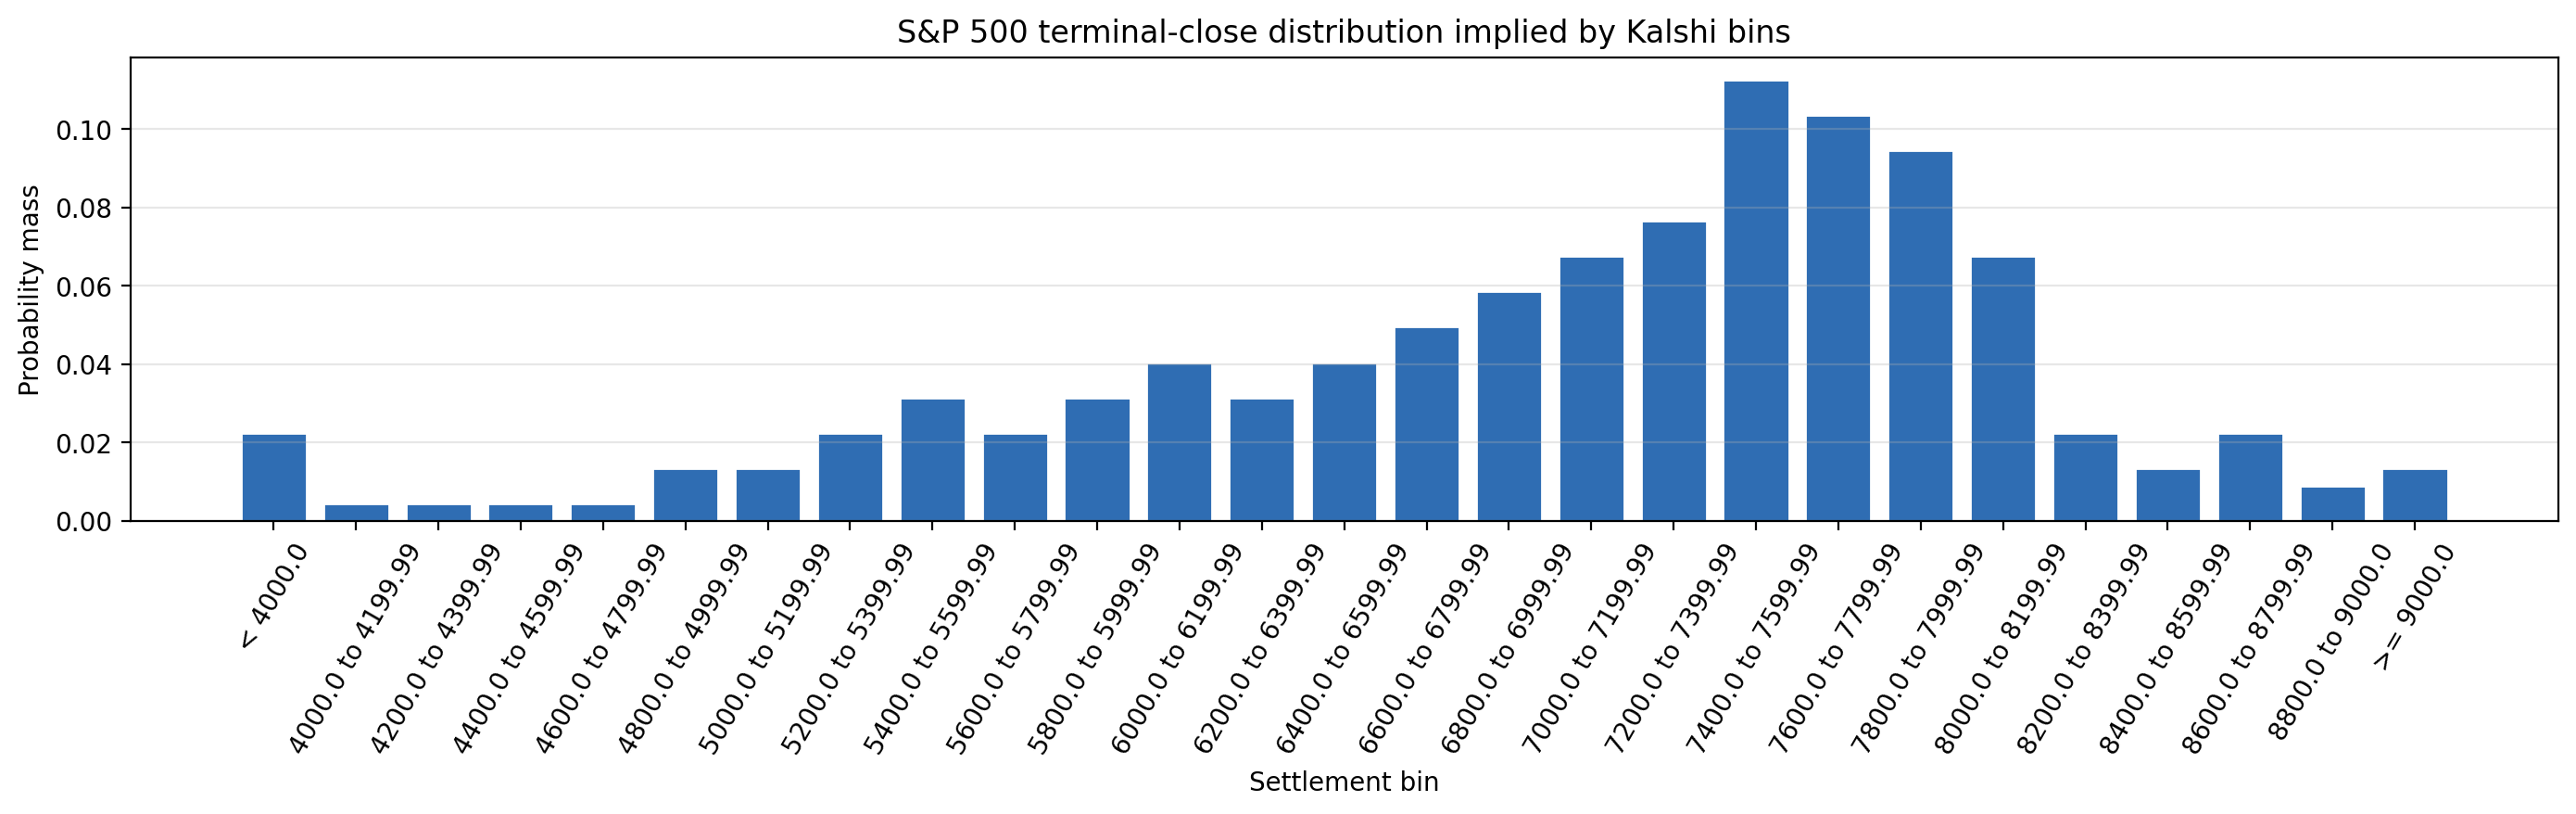

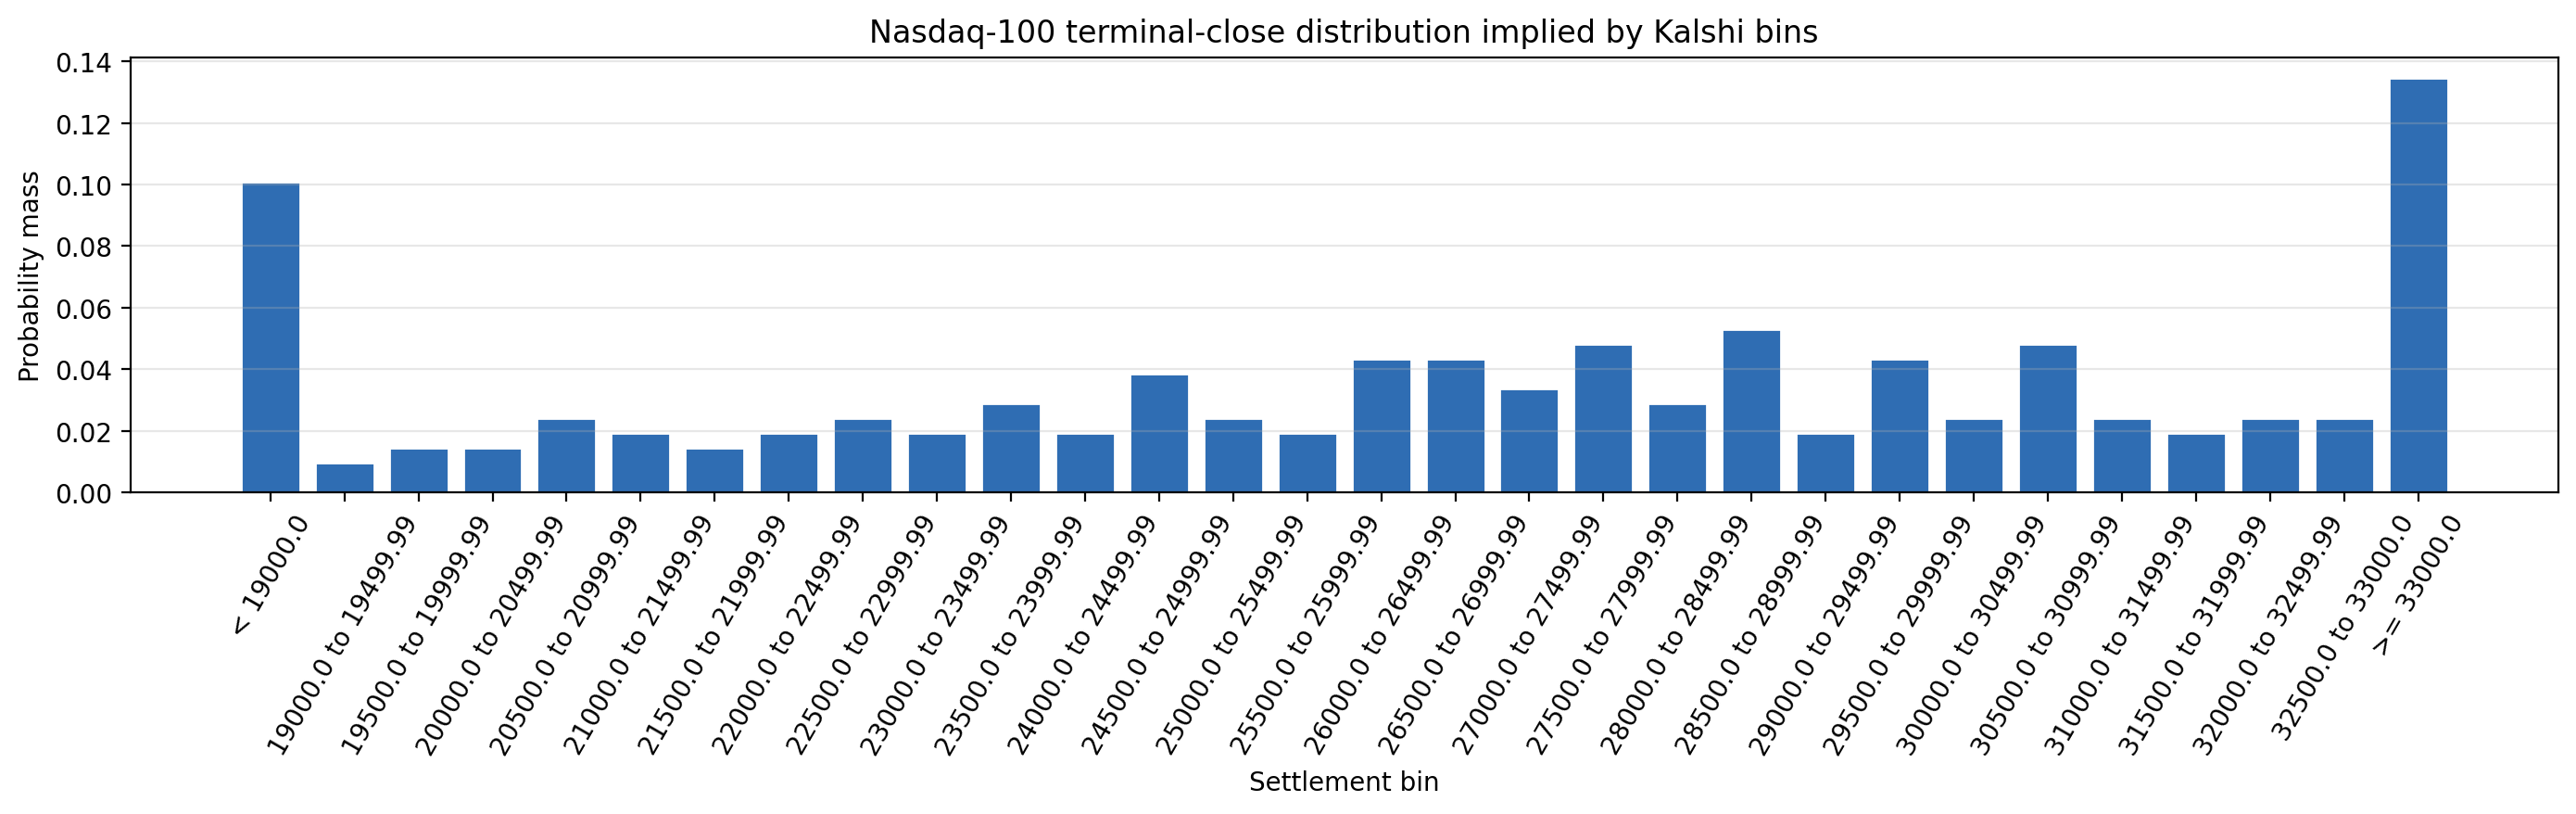

In [61]:
plot_partition_distribution(
    spx_terminal_partition_df,
    title="S&P 500 terminal-close distribution implied by Kalshi bins",
)
plot_partition_distribution(
    ndx_terminal_partition_df,
    title="Nasdaq-100 terminal-close distribution implied by Kalshi bins",
)


In [62]:
print("S&P 500 terminal-close upper tail derived from Kalshi close bins")
display(spx_close_upper_tail_curve_df)
print("S&P 500 terminal-close lower tail derived from Kalshi close bins")
display(spx_close_lower_tail_curve_df)

print("Nasdaq-100 terminal-close upper tail derived from Kalshi close bins")
display(ndx_close_upper_tail_curve_df)
print("Nasdaq-100 terminal-close lower tail derived from Kalshi close bins")
display(ndx_close_lower_tail_curve_df)


S&P 500 terminal-close upper tail derived from Kalshi close bins


,threshold,probability,bin_label
0,4000.0,1.000000,< 4000.0
1,4000.0,0.977477,4000.0 to 4199.99
2,4200.0,0.972973,4200.0 to 4399.99
3,4400.0,0.968468,4400.0 to 4599.99
4,4600.0,0.963964,4600.0 to 4799.99
5,4800.0,0.959459,4800.0 to 4999.99
6,5000.0,0.945946,5000.0 to 5199.99
7,5200.0,0.932432,5200.0 to 5399.99
8,5400.0,0.909910,5400.0 to 5599.99
9,5600.0,0.878378,5600.0 to 5799.99


S&P 500 terminal-close lower tail derived from Kalshi close bins


,threshold,probability,bin_label
0,4000.00,0.022523,< 4000.0
1,4199.99,0.027027,4000.0 to 4199.99
2,4399.99,0.031532,4200.0 to 4399.99
3,4599.99,0.036036,4400.0 to 4599.99
4,4799.99,0.040541,4600.0 to 4799.99
5,4999.99,0.054054,4800.0 to 4999.99
6,5199.99,0.067568,5000.0 to 5199.99
7,5399.99,0.090090,5200.0 to 5399.99
8,5599.99,0.121622,5400.0 to 5599.99
9,5799.99,0.144144,5600.0 to 5799.99


Nasdaq-100 terminal-close upper tail derived from Kalshi close bins


,threshold,probability,bin_label
0,19000.0,1.000000,< 19000.0
1,19000.0,0.899038,19000.0 to 19499.99
2,19500.0,0.889423,19500.0 to 19999.99
3,20000.0,0.875000,20000.0 to 20499.99
4,20500.0,0.860577,20500.0 to 20999.99
5,21000.0,0.836538,21000.0 to 21499.99
6,21500.0,0.817308,21500.0 to 21999.99
7,22000.0,0.802885,22000.0 to 22499.99
8,22500.0,0.783654,22500.0 to 22999.99
9,23000.0,0.759615,23000.0 to 23499.99


Nasdaq-100 terminal-close lower tail derived from Kalshi close bins


,threshold,probability,bin_label
0,19000.00,0.100962,< 19000.0
1,19499.99,0.110577,19000.0 to 19499.99
2,19999.99,0.125000,19500.0 to 19999.99
3,20499.99,0.139423,20000.0 to 20499.99
4,20999.99,0.163462,20500.0 to 20999.99
5,21499.99,0.182692,21000.0 to 21499.99
6,21999.99,0.197115,21500.0 to 21999.99
7,22499.99,0.216346,22000.0 to 22499.99
8,22999.99,0.240385,22500.0 to 22999.99
9,23499.99,0.259615,23000.0 to 23499.99


In [63]:
print("S&P 500 annual max survival ladder")
display(
    spx_max_curve_df[
        [
            "market_ticker",
            "threshold",
            "mid_prob",
            "adjacent_prob_change",
            "monotone_ok",
        ]
    ]
)

print("S&P 500 annual max bucketized approximation")
display(
    spx_max_bucket_df[
        [
            "market_ticker",
            "bucket_low",
            "bucket_high",
            "bucket_prob_mid",
        ]
    ]
)

print("S&P 500 annual min CDF ladder")
display(
    spx_min_curve_df[
        [
            "market_ticker",
            "threshold",
            "mid_prob",
            "adjacent_prob_change",
            "monotone_ok",
        ]
    ]
)

print("S&P 500 annual min bucketized approximation")
display(
    spx_min_bucket_df[
        [
            "market_ticker",
            "bucket_low",
            "bucket_high",
            "bucket_prob_mid",
        ]
    ]
)


S&P 500 annual max survival ladder


,market_ticker,threshold,mid_prob,adjacent_prob_change,monotone_ok
0,KXINXMAXY-01JAN2027-7199.99,7199.99,0.9340,NaN,True
1,KXINXMAXY-01JAN2027-7399.99,7399.99,0.7695,0.1645,True
2,KXINXMAXY-01JAN2027-7599.99,7599.99,0.5725,0.1970,True
3,KXINXMAXY-01JAN2027-7799.99,7799.99,0.4235,0.1490,True
4,KXINXMAXY-01JAN2027-7999.99,7999.99,0.2925,0.1310,True
5,KXINXMAXY-01JAN2027-8199.99,8199.99,0.2370,0.0555,True
6,KXINXMAXY-01JAN2027-8399.99,8399.99,0.1635,0.0735,True
7,KXINXMAXY-01JAN2027-8599.99,8599.99,0.0995,0.0640,True
8,KXINXMAXY-01JAN2027-8799.99,8799.99,0.0600,0.0395,True
9,KXINXMAXY-01JAN2027-8999.99,8999.99,0.0515,0.0085,True


S&P 500 annual max bucketized approximation


,market_ticker,bucket_low,bucket_high,bucket_prob_mid
0,KXINXMAXY-01JAN2027-7199.99,7199.99,7399.99,0.1645
1,KXINXMAXY-01JAN2027-7399.99,7399.99,7599.99,0.1970
2,KXINXMAXY-01JAN2027-7599.99,7599.99,7799.99,0.1490
3,KXINXMAXY-01JAN2027-7799.99,7799.99,7999.99,0.1310
4,KXINXMAXY-01JAN2027-7999.99,7999.99,8199.99,0.0555
5,KXINXMAXY-01JAN2027-8199.99,8199.99,8399.99,0.0735
6,KXINXMAXY-01JAN2027-8399.99,8399.99,8599.99,0.0640
7,KXINXMAXY-01JAN2027-8599.99,8599.99,8799.99,0.0395
8,KXINXMAXY-01JAN2027-8799.99,8799.99,8999.99,0.0085
9,KXINXMAXY-01JAN2027-8999.99,8999.99,NaN,0.0515


S&P 500 annual min CDF ladder


,market_ticker,threshold,mid_prob,adjacent_prob_change,monotone_ok
0,KXINXMINY-01JAN2027-5900.01,5900.01,0.3600,NaN,True
1,KXINXMINY-01JAN2027-6000.01,6000.01,0.3305,-0.0295,False
2,KXINXMINY-01JAN2027-6100.01,6100.01,0.4450,0.1145,True
3,KXINXMINY-01JAN2027-6200.01,6200.01,0.4820,0.0370,True
4,KXINXMINY-01JAN2027-6300.01,6300.01,0.5445,0.0625,True


S&P 500 annual min bucketized approximation


,market_ticker,bucket_low,bucket_high,bucket_prob_mid
0,KXINXMINY-01JAN2027-5900.01,NaN,5900.01,0.3600
1,KXINXMINY-01JAN2027-6000.01,5900.01,6000.01,-0.0295
2,KXINXMINY-01JAN2027-6100.01,6000.01,6100.01,0.1145
3,KXINXMINY-01JAN2027-6200.01,6100.01,6200.01,0.0370
4,KXINXMINY-01JAN2027-6300.01,6200.01,6300.01,0.0625


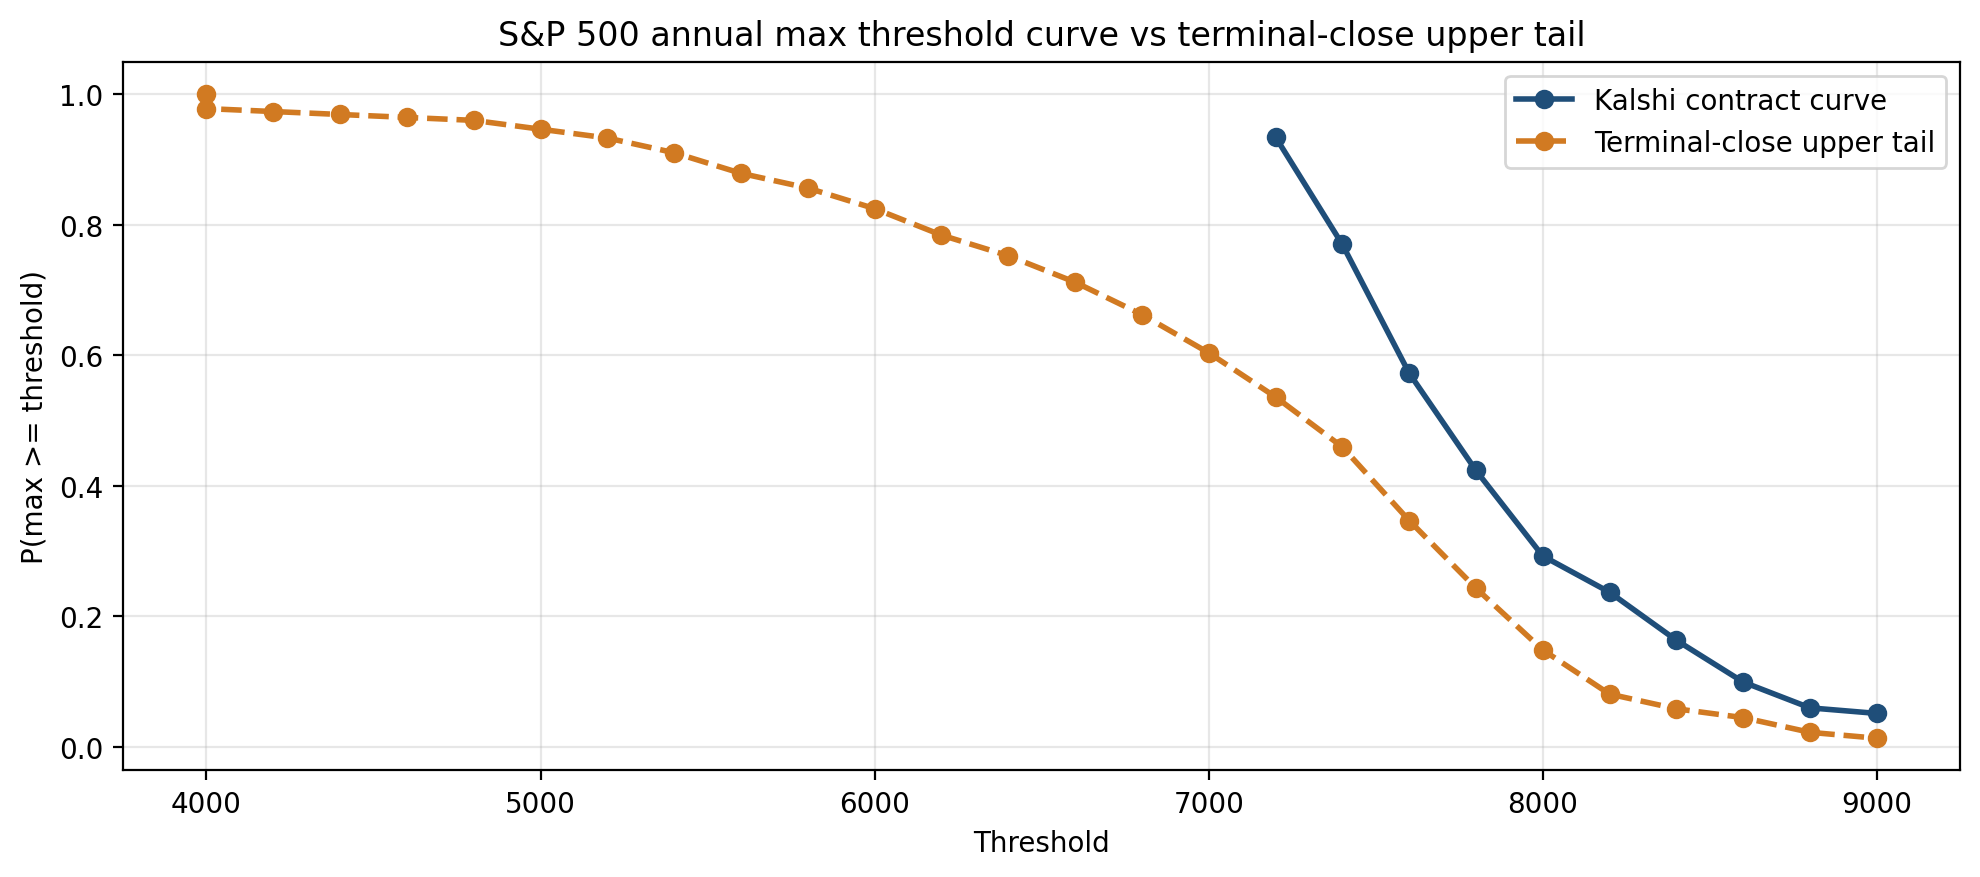

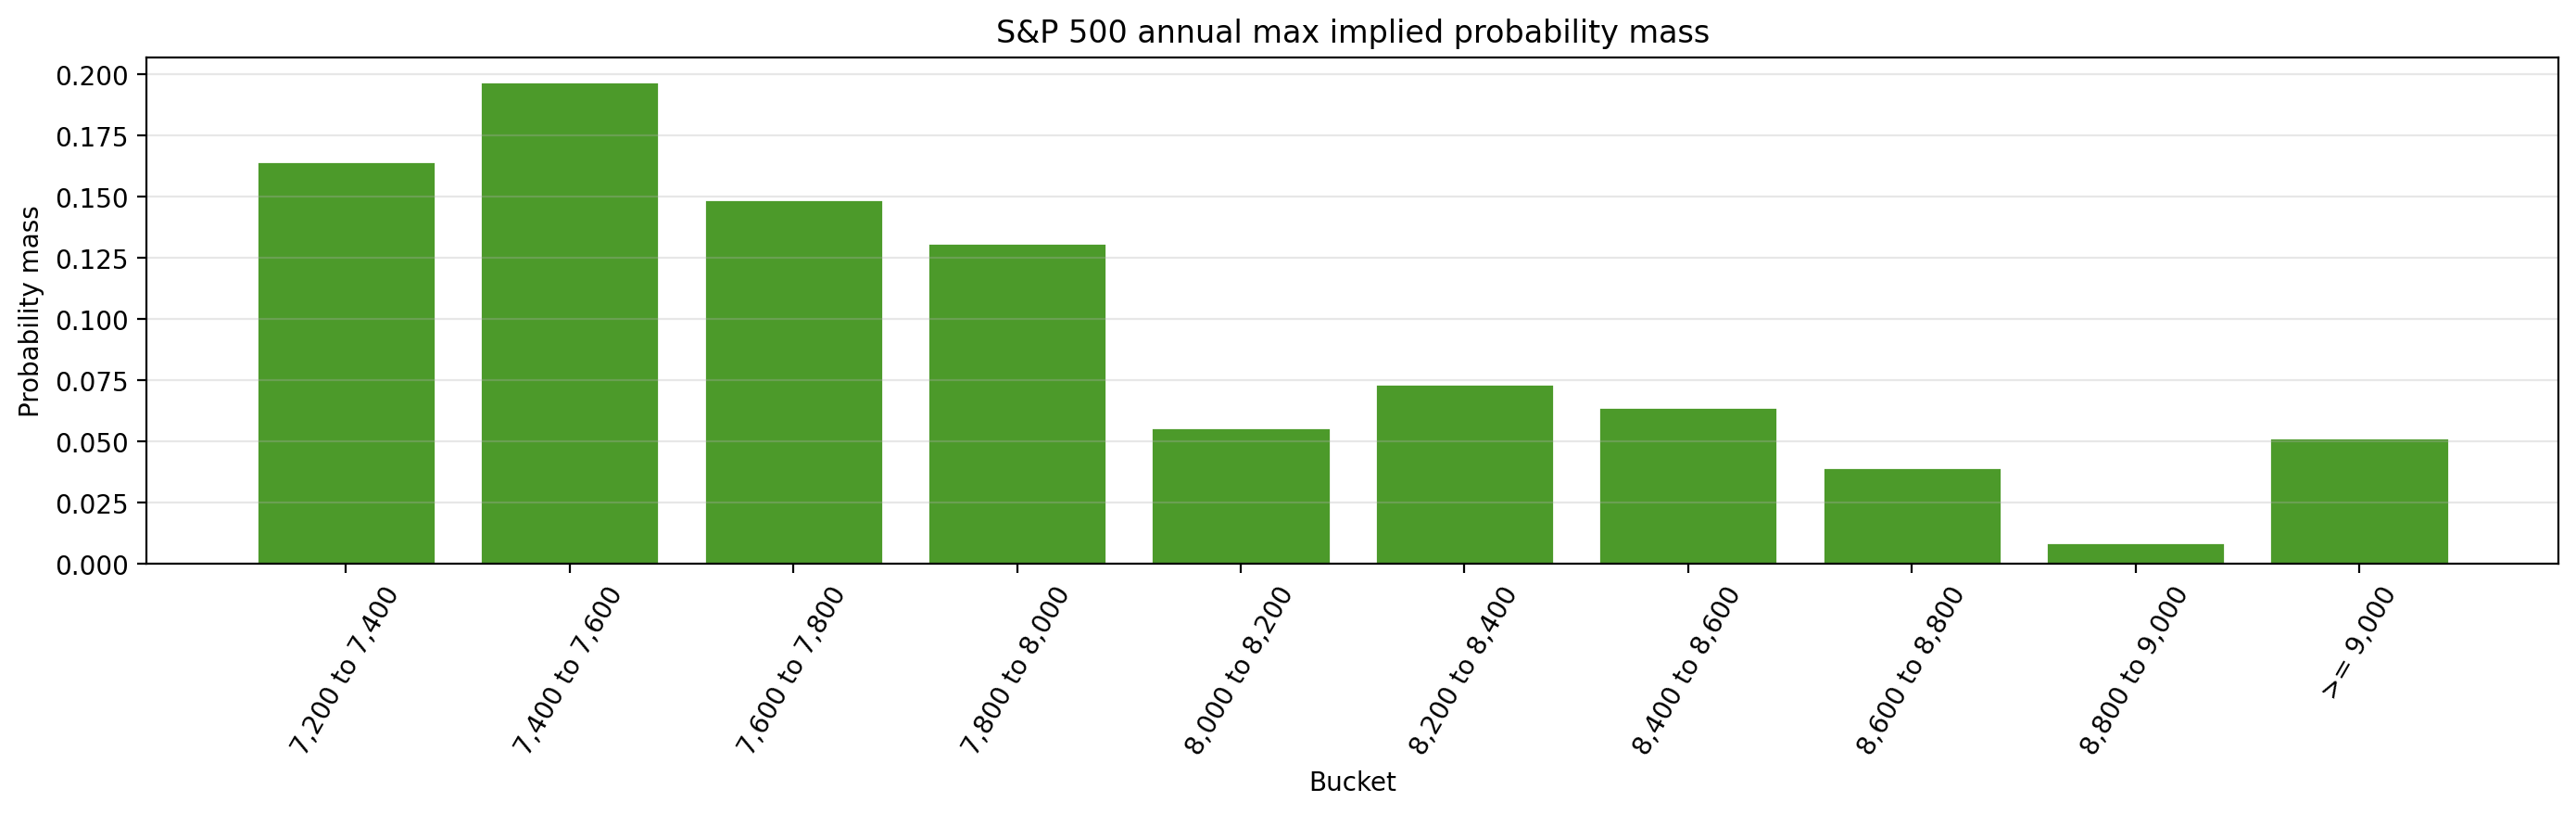

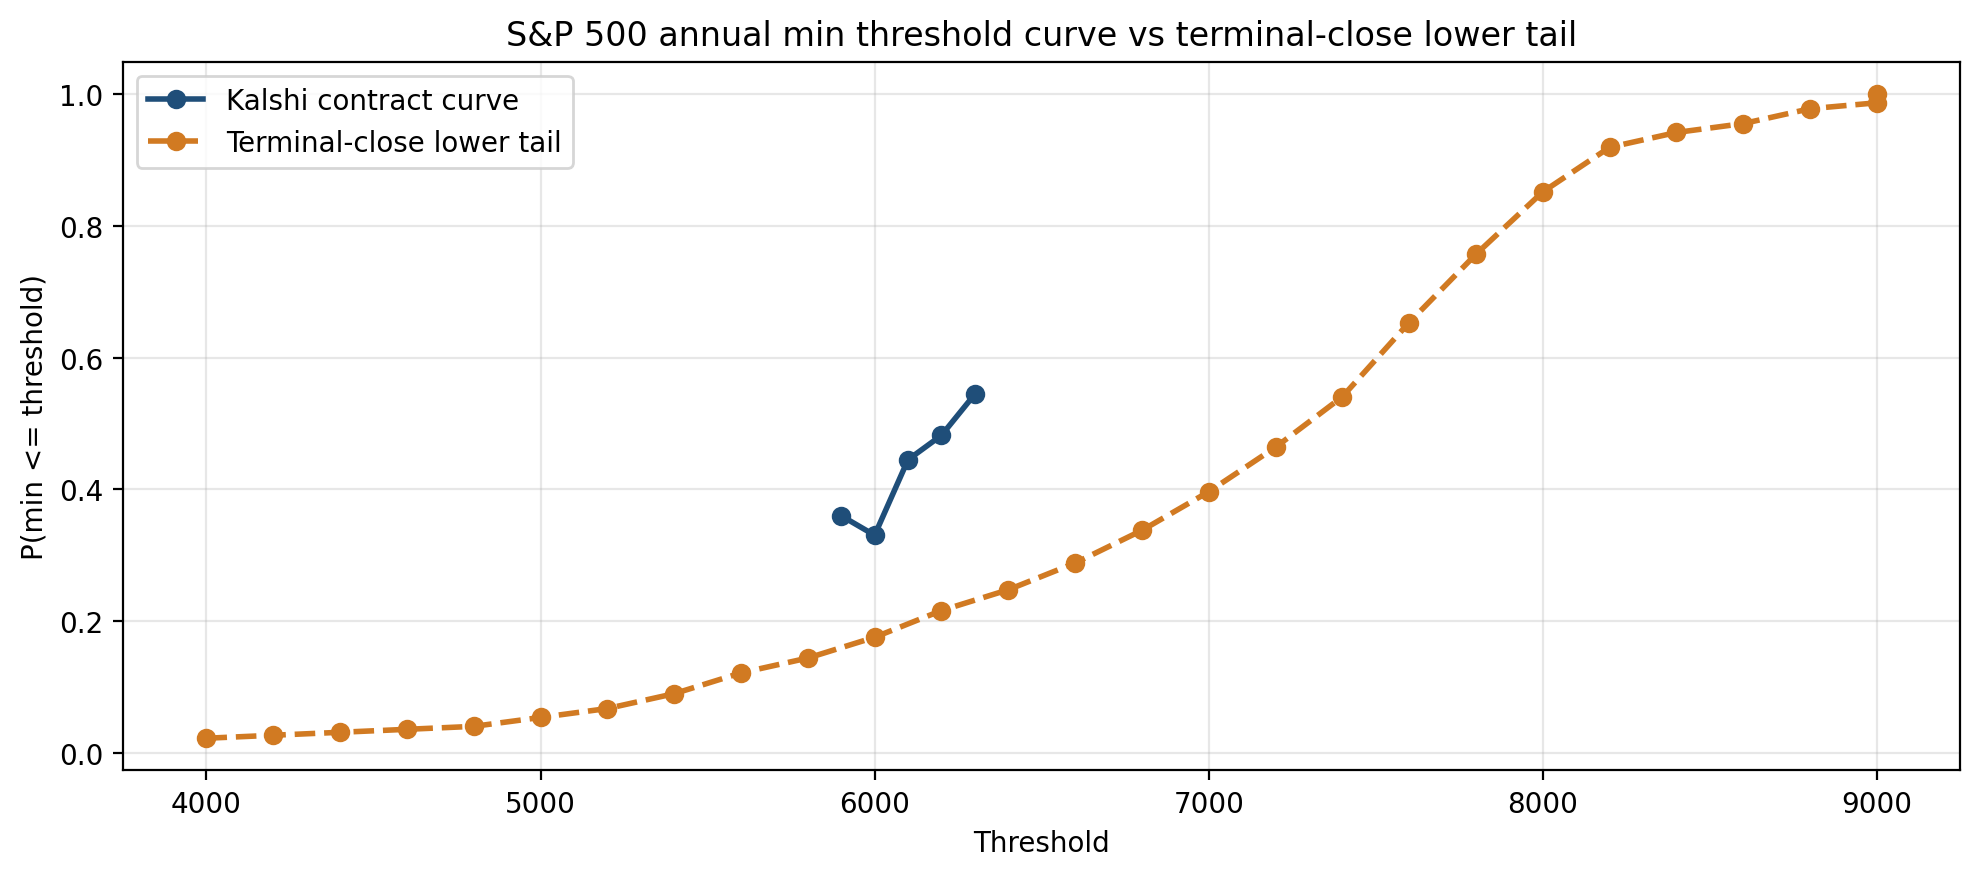

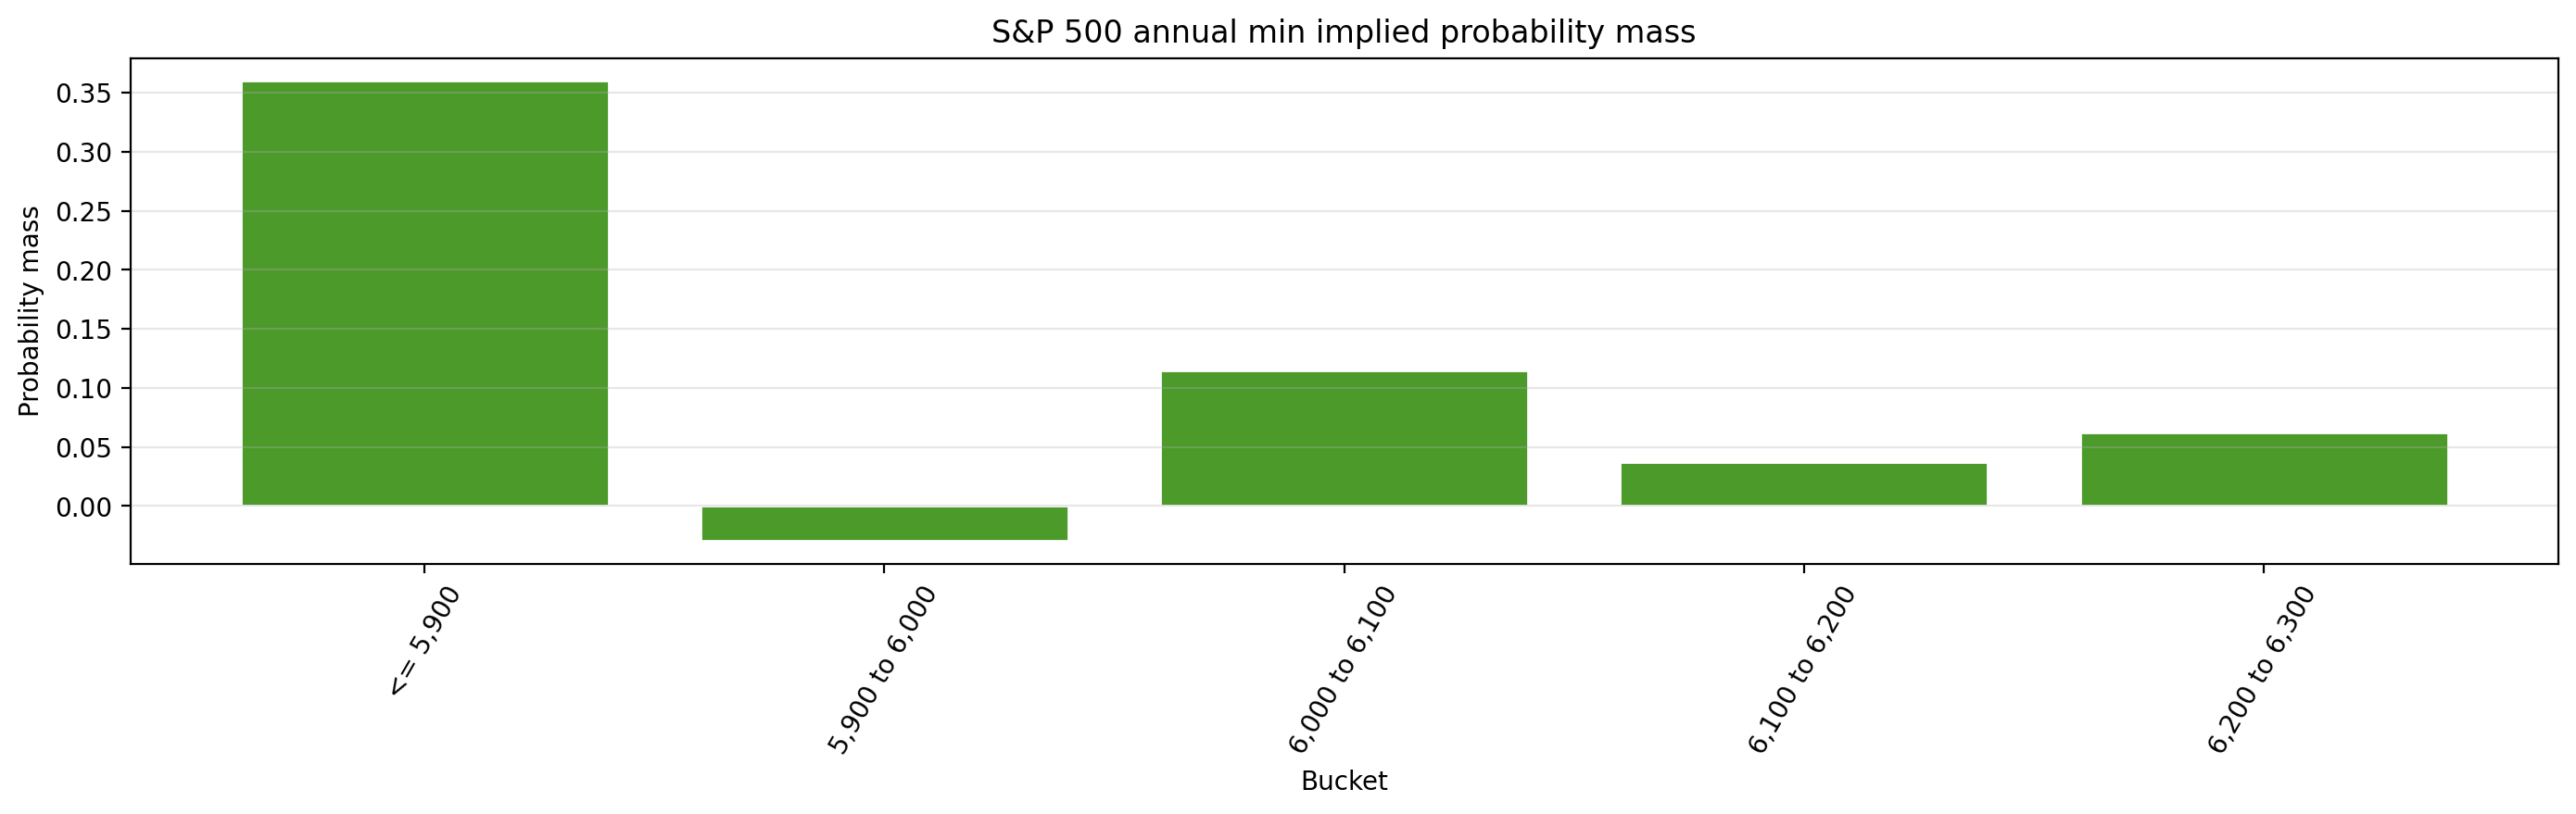

In [64]:
plot_curve_with_reference(
    spx_max_curve_df,
    title="S&P 500 annual max threshold curve vs terminal-close upper tail",
    reference_df=spx_close_upper_tail_curve_df,
    reference_label="Terminal-close upper tail",
)
plot_bucket_probabilities(
    spx_max_bucket_df,
    title="S&P 500 annual max implied probability mass",
)
plot_curve_with_reference(
    spx_min_curve_df,
    title="S&P 500 annual min threshold curve vs terminal-close lower tail",
    reference_df=spx_close_lower_tail_curve_df,
    reference_label="Terminal-close lower tail",
)
plot_bucket_probabilities(
    spx_min_bucket_df,
    title="S&P 500 annual min implied probability mass",
)


In [39]:
print("Nasdaq-100 annual max survival ladder")
display(
    ndx_max_curve_df[
        [
            "market_ticker",
            "threshold",
            "mid_prob",
            "adjacent_prob_change",
            "monotone_ok",
        ]
    ]
)

print("Nasdaq-100 annual max bucketized approximation")
display(
    ndx_max_bucket_df[
        [
            "market_ticker",
            "bucket_low",
            "bucket_high",
            "bucket_prob_mid",
        ]
    ]
)

print("Nasdaq-100 annual min CDF ladder")
display(
    ndx_min_curve_df[
        [
            "market_ticker",
            "threshold",
            "mid_prob",
            "adjacent_prob_change",
            "monotone_ok",
        ]
    ]
)

print("Nasdaq-100 annual min bucketized approximation")
display(
    ndx_min_bucket_df[
        [
            "market_ticker",
            "bucket_low",
            "bucket_high",
            "bucket_prob_mid",
        ]
    ]
)


Nasdaq-100 annual max survival ladder


,market_ticker,threshold,mid_prob,adjacent_prob_change,monotone_ok
0,KXNASDAQ100MAXY-26DEC31H1600-T26799.99,26799.99,0.9760,NaN,True
1,KXNASDAQ100MAXY-26DEC31H1600-T26999.99,26999.99,0.9765,-0.0005,False
2,KXNASDAQ100MAXY-26DEC31H1600-T27199.99,27199.99,0.9765,0.0000,True
3,KXNASDAQ100MAXY-26DEC31H1600-T27399.99,27399.99,0.9665,0.0100,True
4,KXNASDAQ100MAXY-26DEC31H1600-T27599.99,27599.99,0.9515,0.0150,True
5,KXNASDAQ100MAXY-26DEC31H1600-T27799.99,27799.99,0.9075,0.0440,True
6,KXNASDAQ100MAXY-26DEC31H1600-T27999.99,27999.99,0.8780,0.0295,True
7,KXNASDAQ100MAXY-26DEC31H1600-T28199.99,28199.99,0.8555,0.0225,True
8,KXNASDAQ100MAXY-26DEC31H1600-T28399.99,28399.99,0.8080,0.0475,True
9,KXNASDAQ100MAXY-26DEC31H1600-T28599.99,28599.99,0.7880,0.0200,True


Nasdaq-100 annual max bucketized approximation


,market_ticker,bucket_low,bucket_high,bucket_prob_mid
0,KXNASDAQ100MAXY-26DEC31H1600-T26799.99,26799.99,26999.99,-0.0005
1,KXNASDAQ100MAXY-26DEC31H1600-T26999.99,26999.99,27199.99,0.0000
2,KXNASDAQ100MAXY-26DEC31H1600-T27199.99,27199.99,27399.99,0.0100
3,KXNASDAQ100MAXY-26DEC31H1600-T27399.99,27399.99,27599.99,0.0150
4,KXNASDAQ100MAXY-26DEC31H1600-T27599.99,27599.99,27799.99,0.0440
5,KXNASDAQ100MAXY-26DEC31H1600-T27799.99,27799.99,27999.99,0.0295
6,KXNASDAQ100MAXY-26DEC31H1600-T27999.99,27999.99,28199.99,0.0225
7,KXNASDAQ100MAXY-26DEC31H1600-T28199.99,28199.99,28399.99,0.0475
8,KXNASDAQ100MAXY-26DEC31H1600-T28399.99,28399.99,28599.99,0.0200
9,KXNASDAQ100MAXY-26DEC31H1600-T28599.99,28599.99,28799.99,0.0075


Nasdaq-100 annual min CDF ladder


,market_ticker,threshold,mid_prob,adjacent_prob_change,monotone_ok
0,KXNASDAQ100MINY-26DEC31H1600-T22000.01,22000.01,0.205,NaN,True
1,KXNASDAQ100MINY-26DEC31H1600-T22200.01,22200.01,0.210,0.005,True
2,KXNASDAQ100MINY-26DEC31H1600-T22400.01,22400.01,0.230,0.020,True
3,KXNASDAQ100MINY-26DEC31H1600-T22600.01,22600.01,0.250,0.020,True
4,KXNASDAQ100MINY-26DEC31H1600-T22800.01,22800.01,0.285,0.035,True


Nasdaq-100 annual min bucketized approximation


,market_ticker,bucket_low,bucket_high,bucket_prob_mid
0,KXNASDAQ100MINY-26DEC31H1600-T22000.01,NaN,22000.01,0.205
1,KXNASDAQ100MINY-26DEC31H1600-T22200.01,22000.01,22200.01,0.005
2,KXNASDAQ100MINY-26DEC31H1600-T22400.01,22200.01,22400.01,0.020
3,KXNASDAQ100MINY-26DEC31H1600-T22600.01,22400.01,22600.01,0.020
4,KXNASDAQ100MINY-26DEC31H1600-T22800.01,22600.01,22800.01,0.035


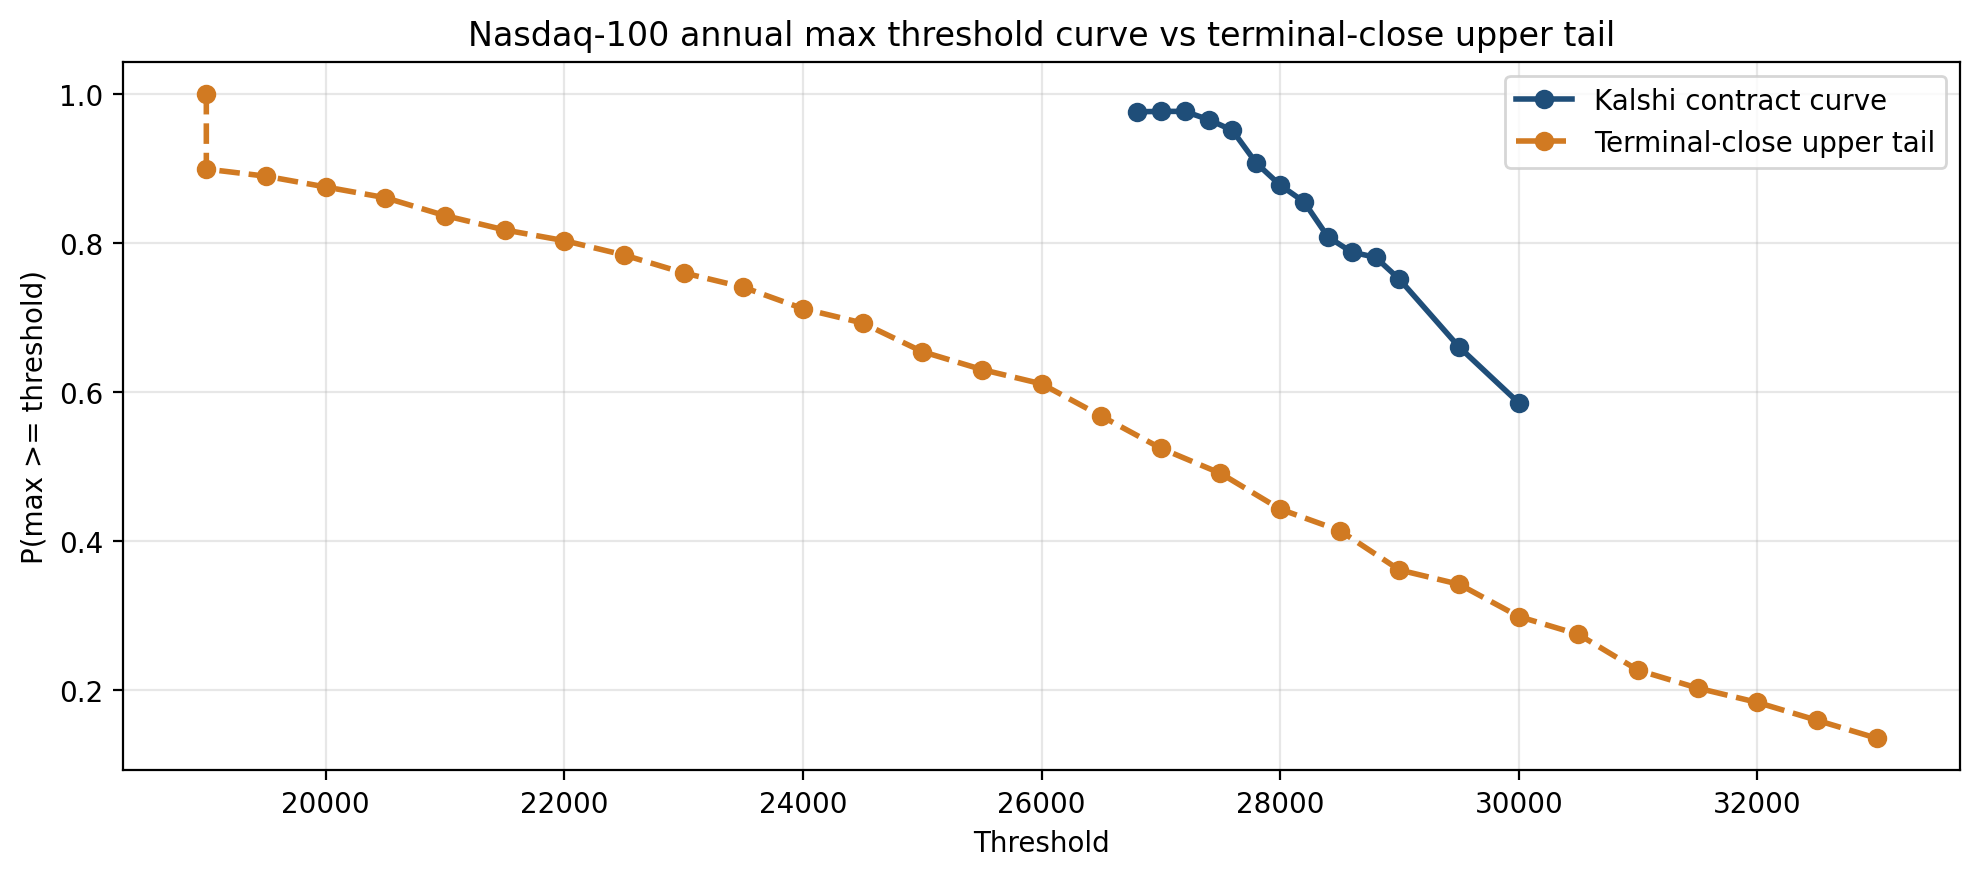

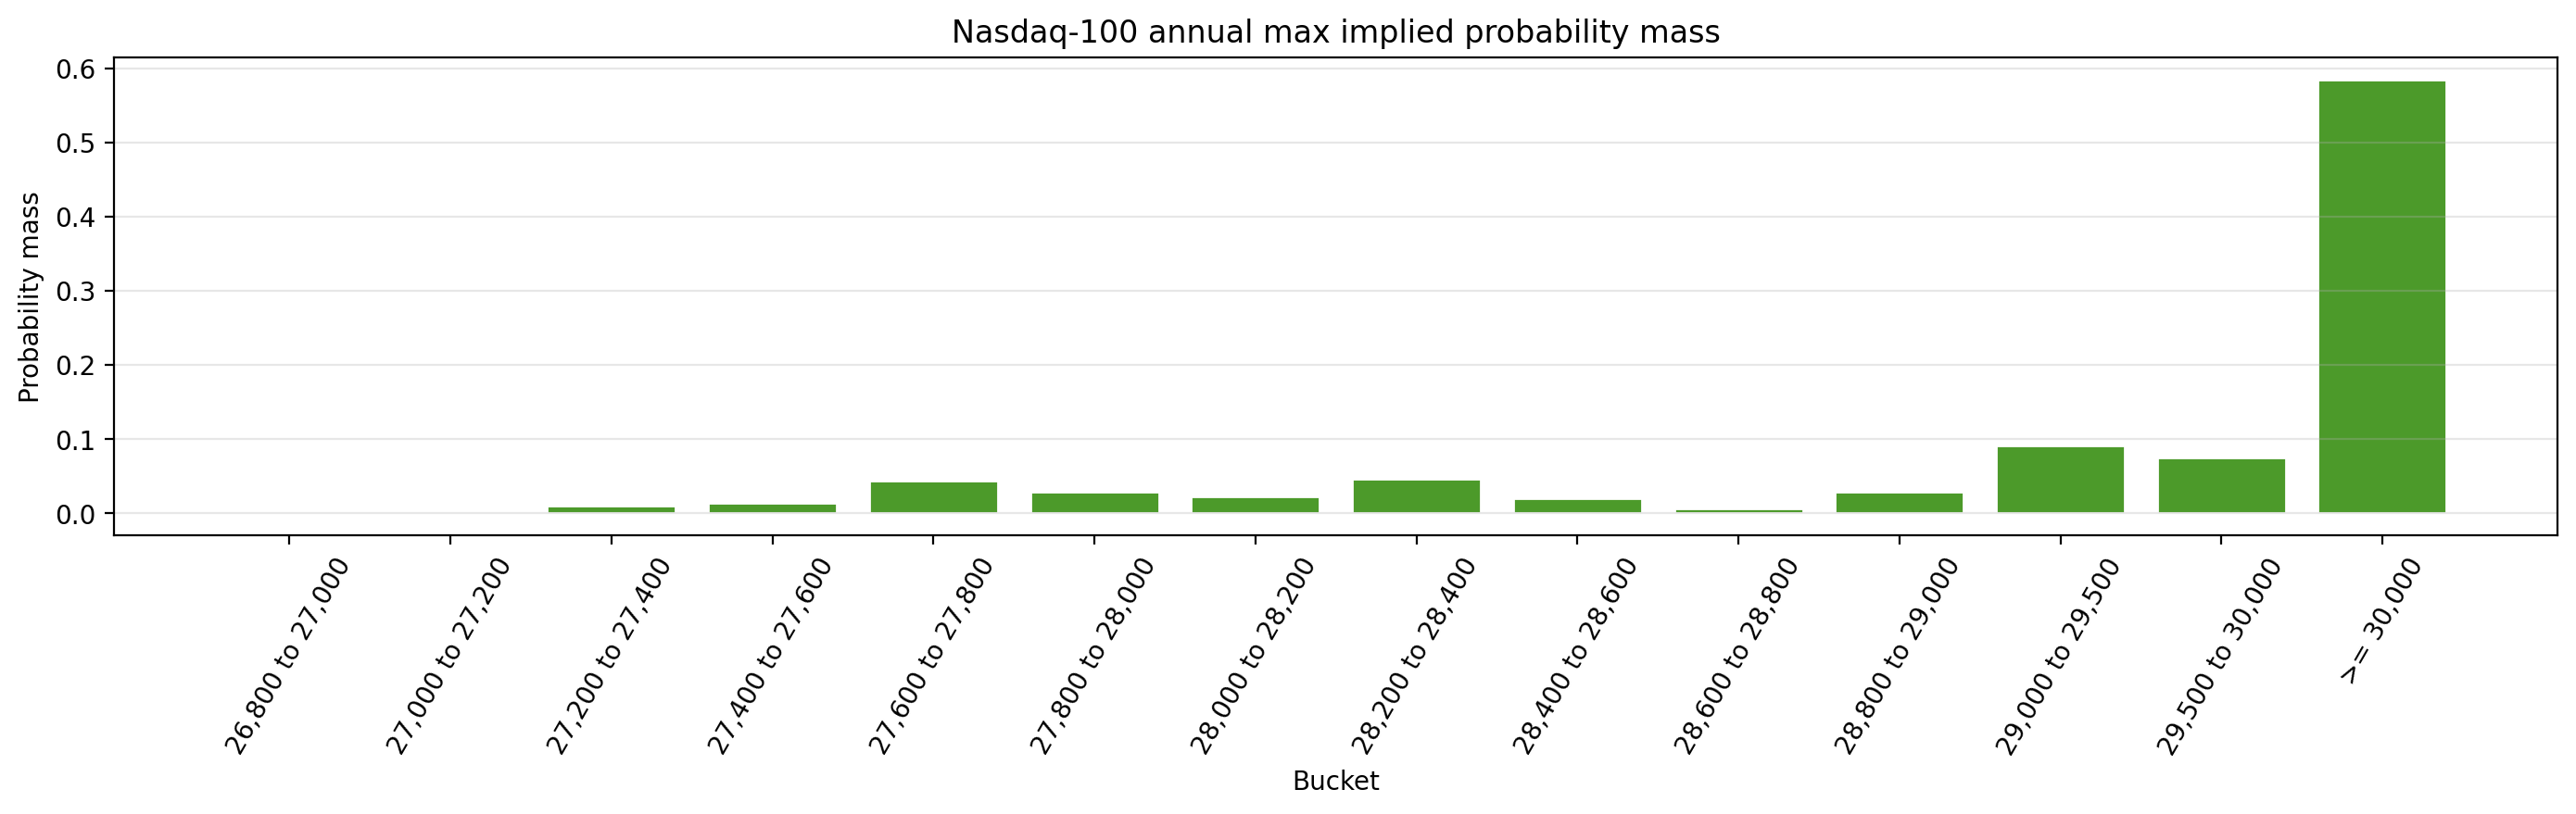

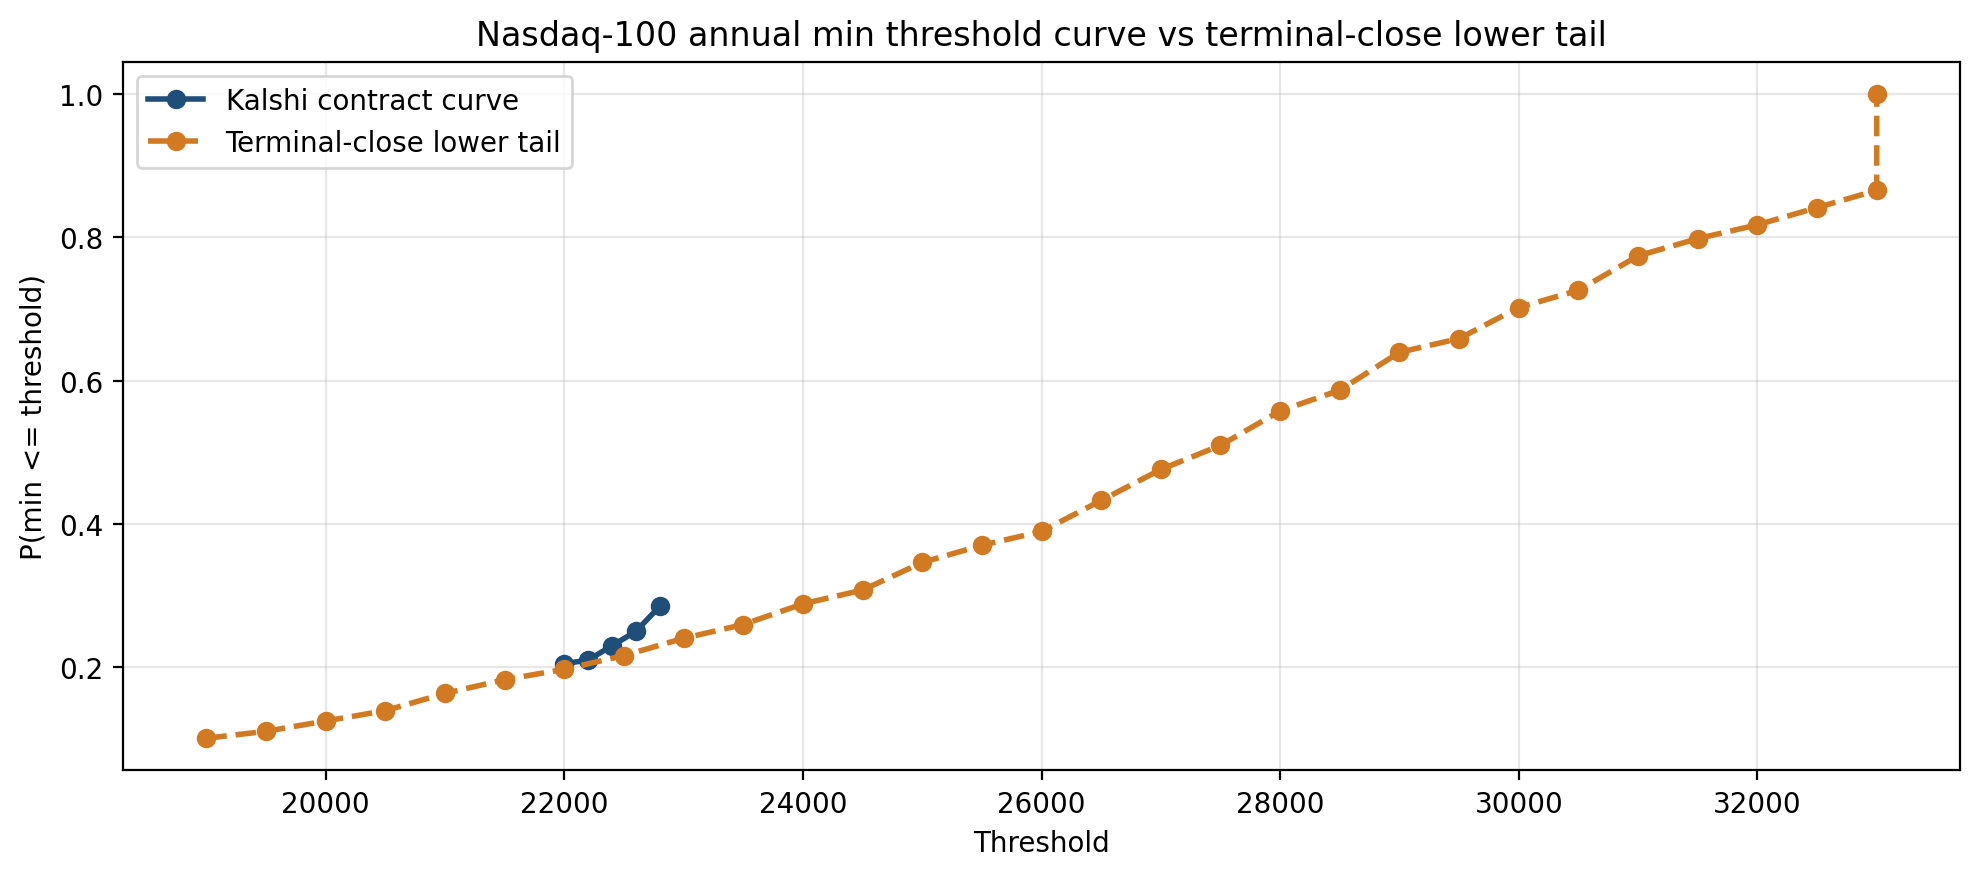

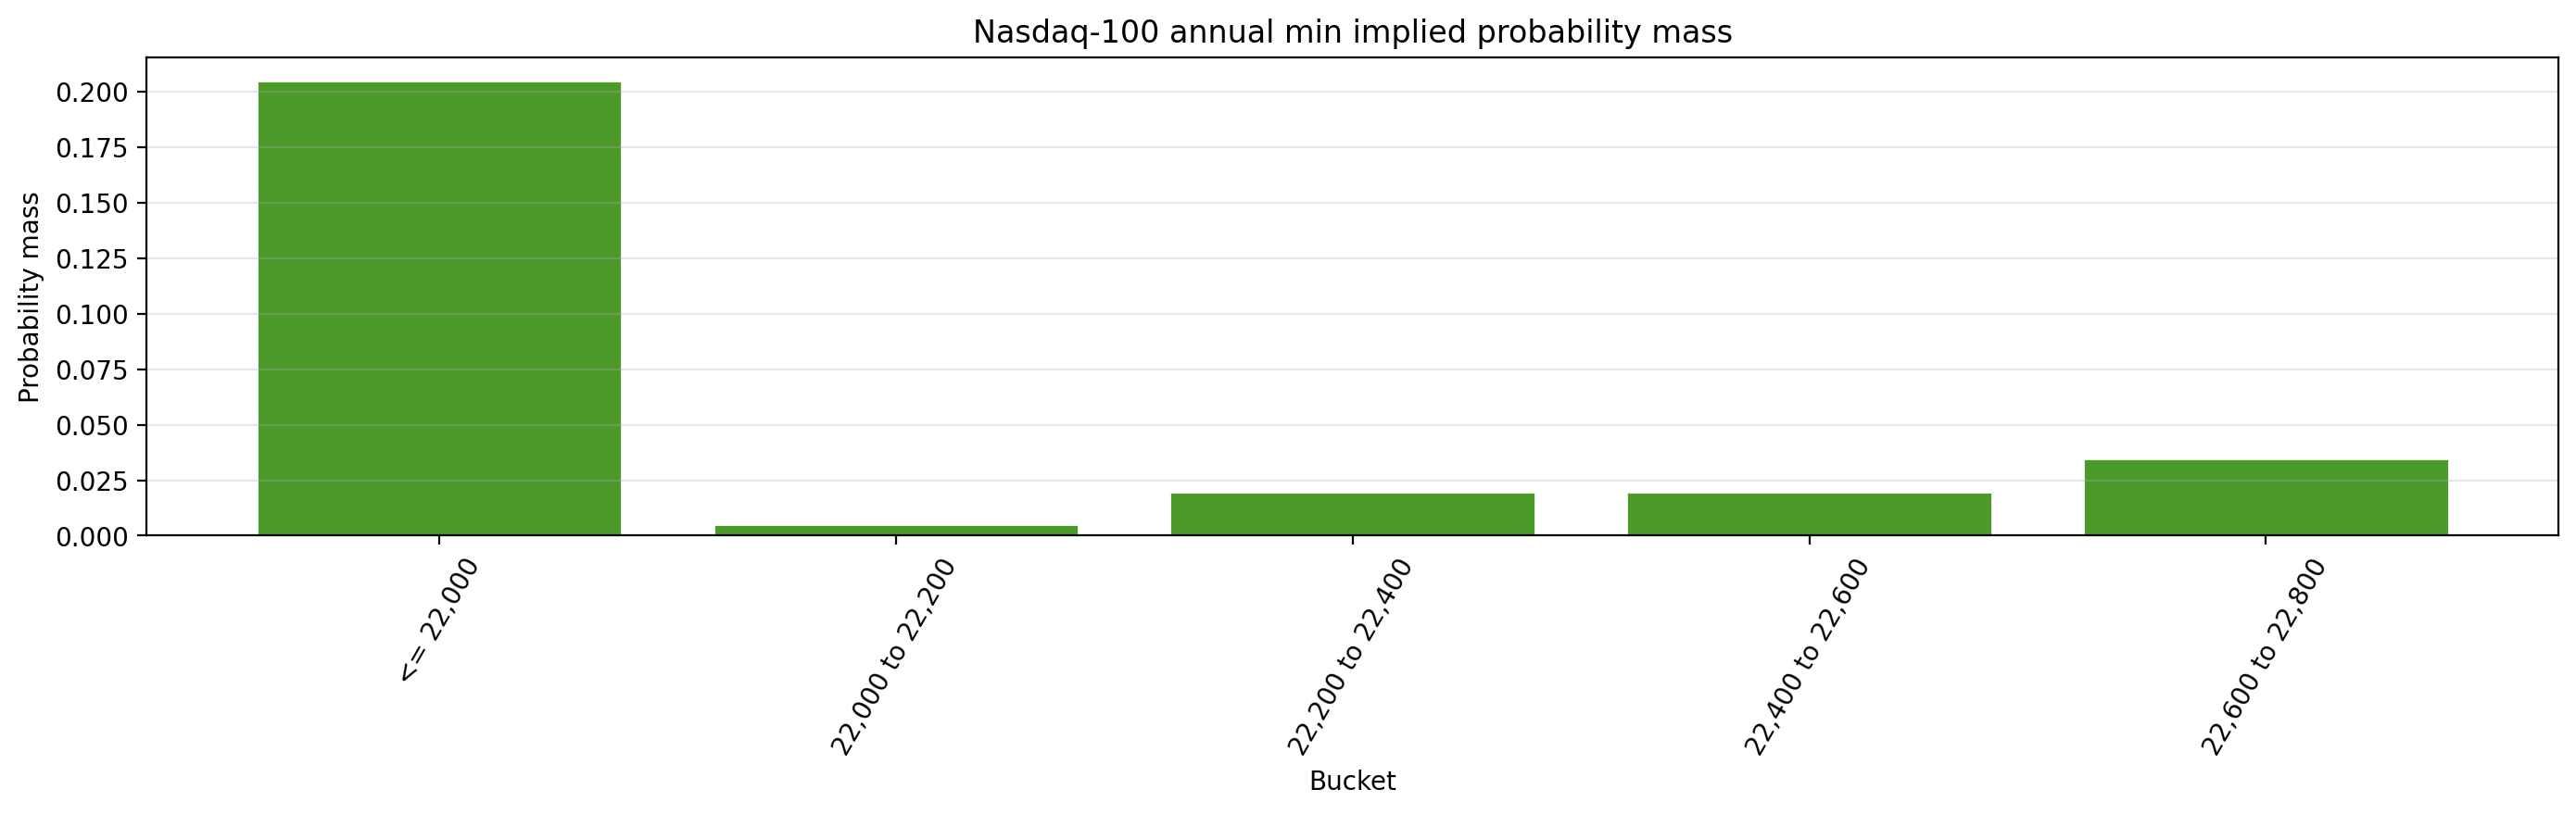

In [65]:
plot_curve_with_reference(
    ndx_max_curve_df,
    title="Nasdaq-100 annual max threshold curve vs terminal-close upper tail",
    reference_df=ndx_close_upper_tail_curve_df,
    reference_label="Terminal-close upper tail",
)
plot_bucket_probabilities(
    ndx_max_bucket_df,
    title="Nasdaq-100 annual max implied probability mass",
)
plot_curve_with_reference(
    ndx_min_curve_df,
    title="Nasdaq-100 annual min threshold curve vs terminal-close lower tail",
    reference_df=ndx_close_lower_tail_curve_df,
    reference_label="Terminal-close lower tail",
)
plot_bucket_probabilities(
    ndx_min_bucket_df,
    title="Nasdaq-100 annual min implied probability mass",
)


In [41]:
print("Standalone terminal threshold checkpoints")
display(
    terminal_reference_df[
        [
            "underlying",
            "market_ticker",
            "threshold",
            "mid_prob",
            "market_title",
        ]
    ]
)


Standalone terminal threshold checkpoints


,underlying,market_ticker,threshold,mid_prob,market_title
19,Nasdaq-100,KXNASDAQ100POS-26DEC31H1600-T25249.85,25249.85,0.660,Will the Nasdaq-100 be above 25249.85 at the e...
65,S&P 500,KXINXPOS-26DEC31H1900-T6845.5,6845.50,0.655,"Will the S&P 500 be above 6845.5 on Dec 31, 20..."


In [42]:
summary_columns = [
    "series_ticker",
    "event_ticker",
    "market_ticker",
    "market_title",
    "status",
    "close_time",
    "last_price",
    "yes_bid",
    "yes_ask",
    "volume",
    "open_interest",
    "liquidity",
]

display(markets_df[[column for column in summary_columns if column in markets_df.columns]])
display(history_summary_df)
display(trade_summary_df)
display(orderbook_summary_df)

if not errors_df.empty:
    display(errors_df)


,series_ticker,event_ticker,market_ticker,market_title,status,close_time
0,KXINXMAXY,KXINXMAXY-01JAN2027,KXINXMAXY-01JAN2027-7199.99,Will the maximum SP500 value reach 7199.99 by ...,active,2027-01-01T11:00:00Z
1,KXINXMAXY,KXINXMAXY-01JAN2027,KXINXMAXY-01JAN2027-7399.99,Will the maximum SP500 value reach 7399.99 by ...,active,2027-01-01T11:00:00Z
2,KXINXMAXY,KXINXMAXY-01JAN2027,KXINXMAXY-01JAN2027-7599.99,Will the maximum SP500 value reach 7599.99 by ...,active,2027-01-01T11:00:00Z
3,KXINXMAXY,KXINXMAXY-01JAN2027,KXINXMAXY-01JAN2027-7799.99,Will the maximum SP500 value reach 7799.99 by ...,active,2027-01-01T11:00:00Z
4,KXINXMAXY,KXINXMAXY-01JAN2027,KXINXMAXY-01JAN2027-7999.99,Will the maximum SP500 value reach 7999.99 by ...,active,2027-01-01T11:00:00Z
...,...,...,...,...,...,...
88,KXNASDAQ100Y,KXNASDAQ100Y-26DEC31H1600,KXNASDAQ100Y-26DEC31H1600-B31750,Will the Nasdaq-100 be between 31500 and 31999...,active,2026-12-31T21:00:00Z
89,KXNASDAQ100Y,KXNASDAQ100Y-26DEC31H1600,KXNASDAQ100Y-26DEC31H1600-B32250,Will the Nasdaq-100 be between 32000 and 32499...,active,2026-12-31T21:00:00Z
90,KXNASDAQ100Y,KXNASDAQ100Y-26DEC31H1600,KXNASDAQ100Y-26DEC31H1600-B32750,Will the Nasdaq-100 be between 32500 and 33000...,active,2026-12-31T21:00:00Z
91,KXNASDAQ100Y,KXNASDAQ100Y-26DEC31H1600,KXNASDAQ100Y-26DEC31H1600-T19000,Will the Nasdaq-100 be below 19000 at the end ...,active,2026-12-31T21:00:00Z


,ticker,series_ticker,source,label,candlestick_count,first_timestamp,last_timestamp,market_ticker
0,KXINXMAXY-01JAN2027-7199.99,KXINXMAXY,live,None,116,2026-01-02T00:00:00+00:00,2026-04-27T00:00:00+00:00,KXINXMAXY-01JAN2027-7199.99
1,KXINXMAXY-01JAN2027-7399.99,KXINXMAXY,live,None,115,2026-01-02T00:00:00+00:00,2026-04-27T00:00:00+00:00,KXINXMAXY-01JAN2027-7399.99
2,KXINXMAXY-01JAN2027-7599.99,KXINXMAXY,live,None,116,2026-01-02T00:00:00+00:00,2026-04-27T00:00:00+00:00,KXINXMAXY-01JAN2027-7599.99
3,KXINXMAXY-01JAN2027-7799.99,KXINXMAXY,live,None,116,2026-01-02T00:00:00+00:00,2026-04-27T00:00:00+00:00,KXINXMAXY-01JAN2027-7799.99
4,KXINXMAXY-01JAN2027-7999.99,KXINXMAXY,live,None,116,2026-01-02T00:00:00+00:00,2026-04-27T00:00:00+00:00,KXINXMAXY-01JAN2027-7999.99
...,...,...,...,...,...,...,...,...
88,KXNASDAQ100Y-26DEC31H1600-B31750,KXNASDAQ100Y,live,None,108,2025-12-24T00:00:00+00:00,2026-04-27T00:00:00+00:00,KXNASDAQ100Y-26DEC31H1600-B31750
89,KXNASDAQ100Y-26DEC31H1600-B32250,KXNASDAQ100Y,live,None,104,2025-12-24T00:00:00+00:00,2026-04-26T00:00:00+00:00,KXNASDAQ100Y-26DEC31H1600-B32250
90,KXNASDAQ100Y-26DEC31H1600-B32750,KXNASDAQ100Y,live,None,107,2025-12-24T00:00:00+00:00,2026-04-26T00:00:00+00:00,KXNASDAQ100Y-26DEC31H1600-B32750
91,KXNASDAQ100Y-26DEC31H1600-T19000,KXNASDAQ100Y,live,None,121,2025-12-24T00:00:00+00:00,2026-04-27T00:00:00+00:00,KXNASDAQ100Y-26DEC31H1600-T19000


,ticker,trade_count,total_contracts,vwap_yes_price_cents,avg_trade_size,first_trade_time,last_trade_time,yes_taker_contract_share,min_yes_price_cents,max_yes_price_cents,sources_used,cutoff_ts
0,KXINXMAXY-01JAN2027-7199.99,1592,165103.34,64.254078,103.708128,2026-02-18T00:08:51.712435+00:00,2026-04-26T15:56:51.815038+00:00,0.470310,21.0,96.0,live,1771977600
1,KXINXMAXY-01JAN2027-7399.99,794,72372.18,45.247319,91.148841,2026-02-18T02:47:45.757525+00:00,2026-04-26T15:12:35.183595+00:00,0.465178,8.0,88.0,live,1771977600
2,KXINXMAXY-01JAN2027-7599.99,536,50293.06,37.529119,93.830336,2026-02-18T09:13:43.212849+00:00,2026-04-26T14:11:48.005629+00:00,0.555839,15.0,69.0,live,1771977600
3,KXINXMAXY-01JAN2027-7799.99,443,55791.64,24.552944,125.940497,2026-02-19T03:12:10.757561+00:00,2026-04-26T20:59:02.330866+00:00,0.646637,5.0,44.0,live,1771977600
4,KXINXMAXY-01JAN2027-7999.99,286,60277.75,15.671641,210.761364,2026-02-18T06:35:38.820594+00:00,2026-04-25T16:24:02.536368+00:00,0.735982,7.9,36.0,live,1771977600
...,...,...,...,...,...,...,...,...,...,...,...,...
88,KXNASDAQ100Y-26DEC31H1600-B31750,31,5981.42,2.466740,192.949032,2026-02-23T04:06:48.962404+00:00,2026-04-26T19:00:32.830660+00:00,0.997827,1.0,3.0,live,1771977600
89,KXNASDAQ100Y-26DEC31H1600-B32250,47,27544.70,1.195031,586.057447,2026-02-26T02:29:23.694767+00:00,2026-04-24T16:28:33.107142+00:00,0.945470,1.0,3.0,live,1771977600
90,KXNASDAQ100Y-26DEC31H1600-B32750,53,25980.99,1.178122,490.207358,2026-02-26T00:34:00.210847+00:00,2026-04-26T00:06:51.324504+00:00,0.998730,1.0,4.0,live,1771977600
91,KXNASDAQ100Y-26DEC31H1600-T19000,1281,690288.79,14.503065,538.867127,2026-02-18T00:15:04.384416+00:00,2026-04-26T20:44:48.065553+00:00,0.897427,1.0,27.0,live,1771977600


,market_ticker,yes_level_count,no_level_count,yes_total_size,no_total_size
0,KXINXMAXY-01JAN2027-7199.99,19,7,20792.87,2710.38
1,KXINXMAXY-01JAN2027-7399.99,14,9,10600.00,6461.00
2,KXINXMAXY-01JAN2027-7599.99,11,15,14028.54,10066.08
3,KXINXMAXY-01JAN2027-7799.99,8,10,7191.00,25639.31
4,KXINXMAXY-01JAN2027-7999.99,7,14,4072.19,38056.31
...,...,...,...,...,...
88,KXNASDAQ100Y-26DEC31H1600-B31750,1,20,6034.24,3337406.82
89,KXNASDAQ100Y-26DEC31H1600-B32250,2,22,6156.32,3329600.62
90,KXNASDAQ100Y-26DEC31H1600-B32750,2,22,5025.00,3332528.01
91,KXNASDAQ100Y-26DEC31H1600-T19000,5,28,11703.29,2787327.25


In [43]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

discovered_markets_df.to_csv(OUTPUT_DIR / "discovered_markets.csv", index=False)
markets_df.to_csv(OUTPUT_DIR / "market_details.csv", index=False)
provenance_df.to_csv(OUTPUT_DIR / "provenance_catalog.csv", index=False)
raw_contract_catalog_df.to_csv(OUTPUT_DIR / "raw_contract_catalog.csv", index=False)
classified_markets_df.to_csv(OUTPUT_DIR / "classified_markets.csv", index=False)
family_summary_df.to_csv(OUTPUT_DIR / "family_summary.csv", index=False)
history_summary_df.to_csv(OUTPUT_DIR / "history_summary.csv", index=False)
trade_summary_df.to_csv(OUTPUT_DIR / "trade_summary.csv", index=False)
orderbook_summary_df.to_csv(OUTPUT_DIR / "orderbook_summary.csv", index=False)
errors_df.to_csv(OUTPUT_DIR / "errors.csv", index=False)
spx_terminal_partition_df.to_csv(OUTPUT_DIR / "spx_terminal_partition.csv", index=False)
ndx_terminal_partition_df.to_csv(OUTPUT_DIR / "ndx_terminal_partition.csv", index=False)
spx_max_curve_df.to_csv(OUTPUT_DIR / "spx_annual_max_curve.csv", index=False)
ndx_max_curve_df.to_csv(OUTPUT_DIR / "ndx_annual_max_curve.csv", index=False)
spx_min_curve_df.to_csv(OUTPUT_DIR / "spx_annual_min_curve.csv", index=False)
ndx_min_curve_df.to_csv(OUTPUT_DIR / "ndx_annual_min_curve.csv", index=False)
spx_max_bucket_df.to_csv(OUTPUT_DIR / "spx_annual_max_buckets.csv", index=False)
ndx_max_bucket_df.to_csv(OUTPUT_DIR / "ndx_annual_max_buckets.csv", index=False)
spx_min_bucket_df.to_csv(OUTPUT_DIR / "spx_annual_min_buckets.csv", index=False)
ndx_min_bucket_df.to_csv(OUTPUT_DIR / "ndx_annual_min_buckets.csv", index=False)
terminal_reference_df.to_csv(OUTPUT_DIR / "terminal_reference_thresholds.csv", index=False)

for ticker, frame in pulled["candlestick_frames"].items():
    frame.to_csv(OUTPUT_DIR / f"{ticker}-candles.csv")

for ticker, frame in pulled["trade_frames"].items():
    frame.to_csv(OUTPUT_DIR / f"{ticker}-trades.csv", index=False)

for ticker, orderbook in pulled["orderbooks"].items():
    with (OUTPUT_DIR / f"{ticker}-orderbook.json").open("w", encoding="utf-8") as handle:
        json.dump(orderbook, handle, indent=2, ensure_ascii=False)

print(f"Wrote exports to {OUTPUT_DIR}")


Wrote exports to c:\Users\nicco\OneDrive\Documents\Github\mykalshi\data\spy_like_market_pull


Focus ticker: KXINXMAXY-01JAN2027-7199.99


,can_close_early,close_time,created_time,early_close_condition,event_ticker,expected_expiration_time,expiration_time,expiration_value,floor_strike,fractional_trading_enabled,last_price_dollars,latest_expiration_time,liquidity_dollars,market_type,no_ask_dollars,no_bid_dollars,no_sub_title,notional_value_dollars,open_interest_fp,open_time,previous_price_dollars,previous_yes_ask_dollars,previous_yes_bid_dollars,price_level_structure,price_ranges,response_price_units,result,rules_primary,rules_secondary,settlement_timer_seconds,status,strike_type,tick_size,ticker,title,updated_time,volume_24h_fp,volume_fp,yes_ask_dollars,yes_ask_size_fp,yes_bid_dollars,yes_bid_size_fp,yes_sub_title,category,series_ticker,series_title,event_title,market_ticker,market_title,market_subtitle,cap_strike,subtitle,occurrence_datetime
0,True,2027-01-01T11:00:00Z,2025-12-22T20:57:01.487262Z,This market will close and expire early if the...,KXINXMAXY-01JAN2027,2027-01-01T05:00:00Z,2027-01-08T05:00:00Z,,7199.99,True,0.9320,2027-01-08T05:00:00Z,0.0000,binary,0.0680,0.0640,"7,200 or above",1.0000,80919.69,2026-01-01T05:00:00Z,0.9390,0.9380,0.9320,deci_cent,"[{'end': '1.0000', 'start': '0.0000', 'step': ...",usd_cent,,If the value of the S&P 500 index value starti...,,1800,active,greater,1,KXINXMAXY-01JAN2027-7199.99,Will the maximum SP500 value reach 7199.99 by ...,2026-04-09T10:33:07.383963Z,80.31,269050.34,0.9360,1000.00,0.9320,119.00,"7,200 or above",Financials,KXINXMAXY,S&P 500 max yearly,How high will the S&P get this year?,KXINXMAXY-01JAN2027-7199.99,Will the maximum SP500 value reach 7199.99 by ...,"7,200 or above",NaN,NaN,NaN


,Open,High,Low,Close,Volume
Date,,,,,
2026-04-23,89.0,92.0,85.0,88.0,1633.77
2026-04-24,90.0,92.0,82.0,89.0,8754.60
2026-04-25,92.0,96.0,92.0,94.0,10008.18
2026-04-26,94.0,94.0,93.0,93.0,43.69
2026-04-27,93.0,93.0,93.0,93.0,50.00


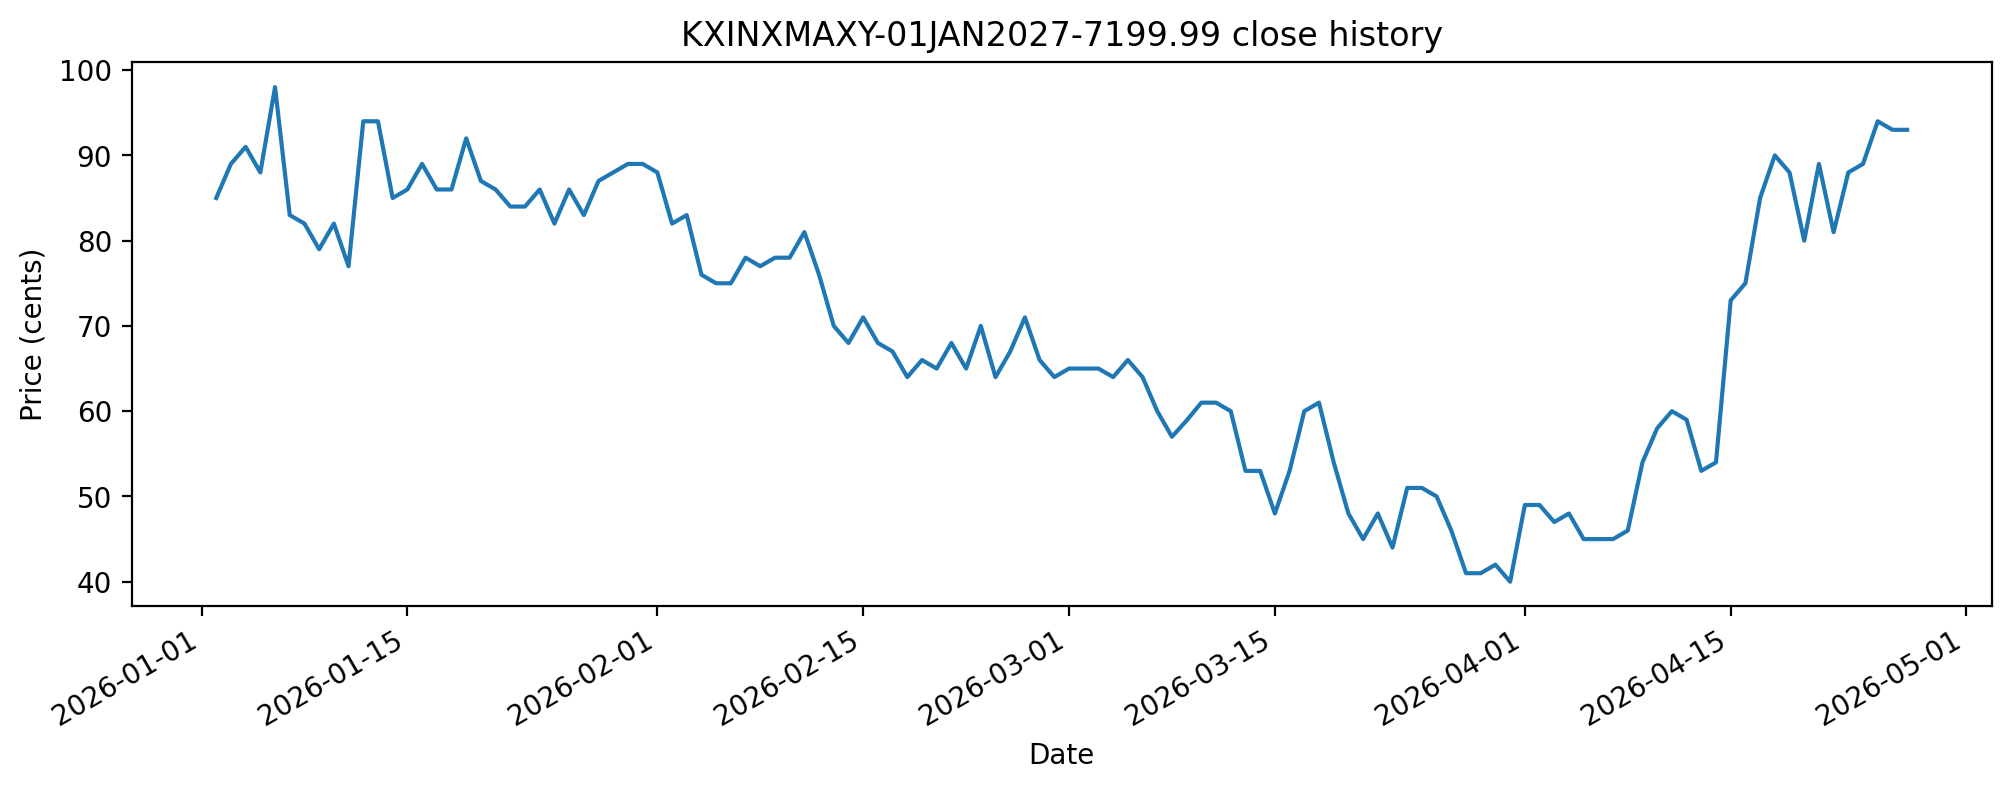

,count_fp,created_time,no_price_dollars,taker_side,ticker,trade_id,yes_price_dollars,contracts,yes_price_cents,notional_cents
1587,6.00,2026-04-25 08:39:53.995160+00:00,0.0680,no,KXINXMAXY-01JAN2027-7199.99,6ab85586-3bc9-5c59-e640-181ef5d27c6f,0.9320,6.00,93.2,559.200
1588,6.38,2026-04-25 18:36:00.123687+00:00,0.0610,no,KXINXMAXY-01JAN2027-7199.99,ea16eea2-dd1e-56e1-3fd1-1acae0fb2805,0.9390,6.38,93.9,599.082
1589,5.31,2026-04-26 01:06:53.011835+00:00,0.0610,yes,KXINXMAXY-01JAN2027-7199.99,24be43d2-45bf-7f4f-8f54-abce54c399d7,0.9390,5.31,93.9,498.609
1590,25.00,2026-04-26 01:27:47.941338+00:00,0.0680,no,KXINXMAXY-01JAN2027-7199.99,4f6c9a19-c821-44ad-414e-dbf3704f94c7,0.9320,25.00,93.2,2330.000
1591,50.00,2026-04-26 15:56:51.815038+00:00,0.0680,no,KXINXMAXY-01JAN2027-7199.99,562ce427-69fd-4ef1-c8dc-26bbf2029e97,0.9320,50.00,93.2,4660.000


In [44]:
if markets_df.empty:
    print("No focus market available.")
else:
    if "volume" in markets_df.columns:
        focus_ticker = markets_df.sort_values("volume", ascending=False).iloc[0]["market_ticker"]
    else:
        focus_ticker = markets_df.iloc[0]["market_ticker"]
    focus_candles = pulled["candlestick_frames"].get(focus_ticker)
    focus_trades = pulled["trade_frames"].get(focus_ticker)

    print("Focus ticker:", focus_ticker)
    display(markets_df.loc[markets_df["market_ticker"] == focus_ticker])
    if focus_candles is not None:
        display(focus_candles.tail())
        if not focus_candles.empty and "Close" in focus_candles.columns:
            ax = focus_candles["Close"].plot(figsize=(12, 4), title=f"{focus_ticker} close history")
            ax.set_ylabel("Price (cents)")
            plt.show()
    if focus_trades is not None:
        display(focus_trades.tail())
